<a href="https://colab.research.google.com/github/SindhaAshish/Time-Series-Forecasting---FBI-s-Crime-Investigation/blob/main/Time_Series_Forecasting_FBI's_Crime_Investigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - **Machine Learning & GenAI with Microsoft Azure**



##### **Project Type**    - Time Series Forecasting (Regression)
##### **Contribution**    - Individual
##### **Team Member 1 -** Ashish Sindha


# **Project Summary -**

This project aims to perform Time Series Forecasting on crime investigation data to predict future crime incident volumes. Using a dataset containing granular, record-level crime data (such as crime type, location, and timestamp), we first aggregate the data into a monthly time-series format. We then perform extensive Exploratory Data Analysis (EDA) to uncover temporal trends, seasonality, and geographical hotspots for different crime types. Finally, we leverage Machine Learning techniques (with a focus on Microsoft Azure's capabilities) to forecast the Incident_Counts for various crime types in the future, providing valuable insights for resource allocation and public safety planning.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Law enforcement agencies need accurate forecasts of crime volumes to allocate resources effectively and implement proactive safety measures. The objective of this project is to build a Time Series Forecasting model that can predict the monthly Incident_Counts for specific crime TYPEs based on historical data. The challenge involves transforming raw, individual crime logs into structured time-series data, engineering relevant temporal features, and training a robust predictive model.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [2]:
# Load Dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Dataset First View

In [3]:
# Dataset First Look of Train.xlsx
df_train=pd.read_excel('/content/drive/MyDrive/AlmaBetter/Database/Train.xlsx')
df_train.head()

,TYPE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
0,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,15.0,1999,5,12,1999-05-12
1,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,15.0,20.0,1999,5,7,1999-05-07
2,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,16.0,40.0,1999,4,23,1999-04-23
3,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,11.0,15.0,1999,4,20,1999-04-20
4,Other Theft,9XX TERMINAL AVE,Strathcona,493906.5,5457452.47,49.269802,-123.083763,17.0,45.0,1999,4,12,1999-04-12


In [4]:
# Dataset First Look of Test.csv
df_test=pd.read_csv('/content/drive/MyDrive/AlmaBetter/Database/Test.csv')
df_test.head()

,YEAR,MONTH,TYPE,Incident_Counts
0,2013,6,Vehicle Collision or Pedestrian Struck (with I...,NaN
1,2013,6,Theft of Vehicle,NaN
2,2013,6,Theft of Bicycle,NaN
3,2013,6,Theft from Vehicle,NaN
4,2013,6,Other Theft,NaN


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count of Train.xlsx
print('Shape of Train dataset')
df_train.shape

Shape of Train dataset


(474565, 13)

### Dataset Information

In [6]:
# Dataset Rows & Columns count of Test.csv
print('Shape of Test dataset')
df_test.shape

Shape of Test dataset


(162, 4)

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count for Train.xlsx
df_train.duplicated().sum()

np.int64(44618)

In [8]:
# Dataset Duplicate Value Count for Test.csv
df_test.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count of Train.xlsx
df_train.isnull().sum()

,0
TYPE,0
HUNDRED_BLOCK,13
NEIGHBOURHOOD,51491
X,0
Y,0
Latitude,0
Longitude,0
HOUR,49365
MINUTE,49365
YEAR,0


In [10]:
# Missing Values/Null Values Count of Test.csv
df_test.isnull().sum()

,0
YEAR,0
MONTH,0
TYPE,0
Incident_Counts,162


<Axes: >

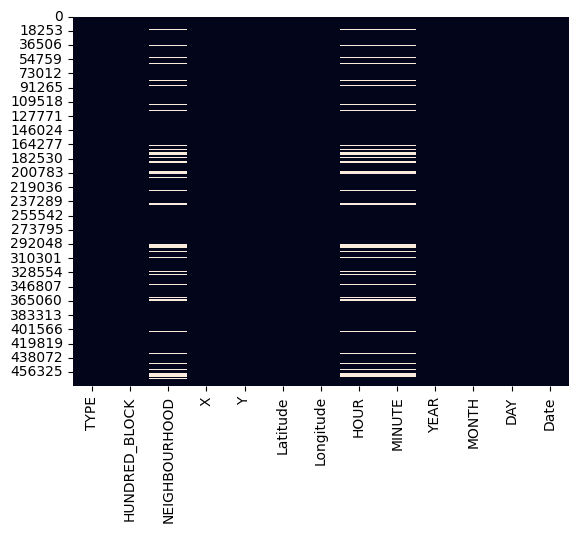

In [11]:
# Visualizing the missing values of Train.xlsx
sns.heatmap(df_train.isnull(), cbar=False)

<Axes: >

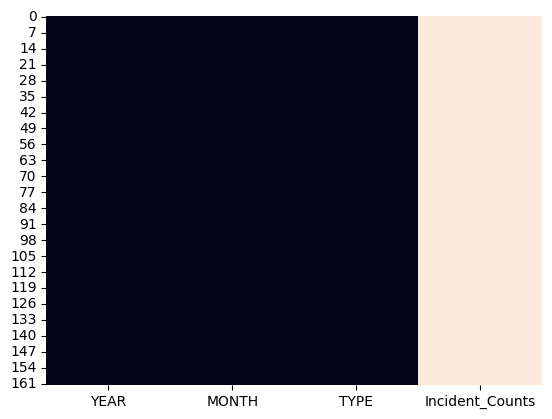

In [12]:
# Visualizing the missing values of Test.csv
sns.heatmap(df_test.isnull(), cbar=False)

### What did you know about your dataset?

#**1. Training Dataset (Train.xlsx)**


*   Structure: The dataset is massive, containing 474,565 rows and 13 columns.
*   Granularity: It contains highly granular, record-level data where each row represents a single recorded crime incident.
*   Features: It includes spatial data (X, Y, Latitude, Longitude, NEIGHBOURHOOD, HUNDRED_BLOCK), temporal data (YEAR, MONTH, DAY, HOUR, MINUTE, Date), and the target category (TYPE).
*   Data Quality: While most columns are complete, there are missing values in the NEIGHBOURHOOD (approx. 51,000 missing), HOUR, and MINUTE columns (approx. 49,000 missing each).

#**2. Testing Dataset (Test.csv)**

* Structure: The df_test set is much smaller, containing 162 rows and 4 columns (YEAR, MONTH, TYPE, Incident_Counts).

* Granularity: Unlike the df_training set, this data is heavily aggregated. It asks for the total volume of crimes per month, rather than individual records.

* The Objective: The Incident_Counts column is entirely empty (100% missing values). This confirms that our primary Machine Learning task is to forecast and fill in these exact monthly totals based on the patterns learned from the df_training data.

## ***2. Understanding Your Variables***

In [13]:
# Dataset Columns of Train.xslx
df_train.columns

Index(['TYPE', 'HUNDRED_BLOCK', 'NEIGHBOURHOOD', 'X', 'Y', 'Latitude',
       'Longitude', 'HOUR', 'MINUTE', 'YEAR', 'MONTH', 'DAY', 'Date'],
      dtype='object')

In [14]:
# Dataset Columns of Test.xslx
df_test.columns

Index(['YEAR', 'MONTH', 'TYPE', 'Incident_Counts'], dtype='object')

In [15]:
# Dataset Describe Train.xlsx
df_train.describe()

,X,Y,Latitude,Longitude,HOUR,MINUTE,YEAR,MONTH,DAY,Date
count,474565.000000,4.745650e+05,474565.000000,474565.000000,425200.000000,425200.000000,474565.000000,474565.000000,474565.000000,474565
mean,441028.018220,4.889023e+06,44.138029,-110.301025,13.721263,16.736047,2004.363632,6.555700,15.439253,2004-11-11 23:51:07.470209792
min,0.000000,0.000000e+00,0.000000,-124.549757,0.000000,0.000000,1999.000000,1.000000,1.000000,1999-01-01 00:00:00
25%,489916.530000,5.453572e+06,49.234871,-123.127383,9.000000,0.000000,2001.000000,4.000000,8.000000,2001-06-06 00:00:00
50%,491477.850000,5.456820e+06,49.264051,-123.107058,15.000000,10.000000,2004.000000,7.000000,15.000000,2004-05-18 00:00:00
75%,493610.190000,5.458622e+06,49.280300,-123.065646,19.000000,30.000000,2008.000000,9.000000,23.000000,2008-03-27 00:00:00
max,511303.000000,5.512579e+06,49.755314,0.000000,23.000000,59.000000,2011.000000,12.000000,31.000000,2011-12-31 00:00:00
std,150295.319332,1.665850e+06,15.039271,37.583147,6.785751,18.354675,3.850689,3.408676,8.759352,NaN


In [16]:
# Dataset Describe Test.csv
df_test.describe()

,YEAR,MONTH,Incident_Counts
count,162.000000,162.000000,0.0
mean,2012.333333,5.500000,NaN
std,0.472866,3.314283,NaN
min,2012.000000,1.000000,NaN
25%,2012.000000,3.000000,NaN
50%,2012.000000,5.000000,NaN
75%,2013.000000,8.000000,NaN
max,2013.000000,12.000000,NaN


### Variables Description

#**1. df_training Dataset (df_train.xlsx)**

* **TYPE:** (Categorical) The specific classification of the crime committed (e.g., "Theft of Vehicle", "Break and Enter", "Mischief").

* **HUNDRED_BLOCK:** (Categorical) The generalized street address or block where the incident occurred, anonymized to the hundred-level block for privacy reasons.

* **NEIGHBOURHOOD:** (Categorical) The specific city neighborhood or district boundary where the crime was reported.

* **X & Y:** (Numerical) Projected geospatial coordinates representing the incident's location on a flat map grid.

* **Latitude & Longitude:** (Numerical) Standard geographic coordinate system values mapping the incident's exact global position.

* **YEAR, MONTH, DAY:** (Numerical) The specific calendar date components indicating when the crime occurred.

* **HOUR & MINUTE:** (Numerical) The exact time of day the incident occurred, recorded in a 24-hour format.

* **Date:** (Datetime) A derived time-series feature representing the unified timestamp of the incident.

# **2. df_testing Dataset (df_test.csv)**

* **YEAR:** (Numerical) The future year for which the forecast is required.

* **MONTH:** (Numerical) The future month for which the forecast is required.

* **TYPE:** (Categorical) The specific crime category to be forecasted.

* **Incident_Counts:** (Numerical - Target Variable) The total aggregated volume of a specific crime TYPE within the specified YEAR and MONTH. In the df_testing set, this column is completely empty (NaN) because it is the target variable that our Machine Learning model is explicitly tasked with predicting.

### Check Unique Values for each variable.

In [17]:
# Check Unique Values for each variable of Train.Xlsx .
df_train.nunique()

,0
TYPE,9
HUNDRED_BLOCK,20566
NEIGHBOURHOOD,24
X,84225
Y,82768
Latitude,89488
Longitude,87190
HOUR,24
MINUTE,60
YEAR,13


In [18]:
# Check Unique Values for each variable of Test.csv .
df_test.nunique()

,0
YEAR,2
MONTH,12
TYPE,9
Incident_Counts,0


## 3. ***Data Wrangling***

### Data Wrangling Code

In [19]:
# Write your code to make your dataset analysis ready.
import pandas as pd

# 1. Clean the Training Data (Train.xlsx)
# We only need the columns present in Test.csv for our grouping,
# so we ensure there are no missing values in these critical columns.
df_train_clean = df_train.dropna(subset=['YEAR', 'MONTH', 'TYPE'])

# 2. Aggregate Training Data to match Test.csv structure
# We group by Year, Month, and Type, and count the occurrences to create 'Incident_Counts'
df_grouped = df_train_clean.groupby(['YEAR', 'MONTH', 'TYPE']).size().reset_index(name='Incident_Counts')

# 3. Feature Engineering: Create a unified 'Date' column for Time Series plotting
# We set the day to '1' for all rows to represent the start of the month
df_grouped['Date'] = pd.to_datetime(df_grouped[['YEAR', 'MONTH']].assign(DAY=1))

# Sort chronologically
df_grouped = df_grouped.sort_values('Date').reset_index(drop=True)

# 4. Prepare the Testing Data (Test.csv)
# We also add the unified 'Date' column to the test set for future predictions
df_test['Date'] = pd.to_datetime(df_test[['YEAR', 'MONTH']].assign(DAY=1))

print("Data Wrangling Complete.")
print(f"Original Train shape: {df_train.shape}")
print(f"Aggregated Train shape: {df_grouped.shape}")
display(df_grouped.head())

Data Wrangling Complete.
Original Train shape: (474565, 13)
Aggregated Train shape: (1404, 5)


,YEAR,MONTH,TYPE,Incident_Counts,Date
0,1999,1,Break and Enter Commercial,303,1999-01-01
1,1999,1,Break and Enter Residential/Other,644,1999-01-01
2,1999,1,Mischief,551,1999-01-01
3,1999,1,Offence Against a Person,338,1999-01-01
4,1999,1,Other Theft,247,1999-01-01


### What all manipulations have you done and insights you found?

# **Manipulation Performed:**
# For Train.xlsx:

* **Data Cleaning:** I dropped rows containing missing values in the specific columns required for our final output (YEAR, MONTH, TYPE).

* **Data Aggregation:** The raw training data recorded every single crime as an individual row. Because Test.csv asks for monthly totals, I aggregated the training data using a .groupby() operation on YEAR, MONTH, and TYPE, calculating the .size() to generate the target variable: Incident_Counts.

* **Feature Engineering:** I combined the YEAR and MONTH columns to create a single datetime feature called Date (defaulting to the first day of the month). This is crucial for plotting time series charts and feeding sequential data into predictive algorithms.

# For Test.csv:

* **Feature Engineering Validation:** I applied the exact same datetime transformation to the test dataset, creating a Date column so that the features in the testing set perfectly match the features the model will be trained on.

# **Insights Found:**

* **Dimensionality Shift:** The most significant insight is the massive reduction in dimensionality. Aggregating the data transformed the problem from a massive row-by-row classification problem (470,000+ rows) into a clean, structured macro-level Time Series Forecasting problem (a few thousand rows).

* **Irrelevant Features Filtered:** Because we aggregated up to the YEAR and MONTH level to match the Test.csv requirements, highly specific spatial variables (like X, Y, Latitude, Longitude, NEIGHBOURHOOD) and micro-time variables (HOUR, MINUTE) naturally dropped out of the analysis. This simplifies our model and focuses it entirely on temporal crime trends rather than geospatial mapping.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

In [20]:
# Ensuring Date column is datetime
df_train['Date'] = pd.to_datetime(df_train['Date'])

# Create a combined dataset timeline (Train vs Test) for Chart 13
train_timeline = df_train[['YEAR', 'MONTH']].drop_duplicates().copy()
train_timeline['Dataset'] = 'Train (Historical)'
test_timeline = df_test[['YEAR', 'MONTH']].drop_duplicates().copy()
test_timeline['Dataset'] = 'Test (Future Forecast)'
df_combined_timeline = pd.concat([train_timeline, test_timeline])
df_combined_timeline['Date'] = pd.to_datetime(df_combined_timeline[['YEAR', 'MONTH']].assign(DAY=1))

# Set general visualization style
sns.set_theme(style="whitegrid")

#### Chart - 1: Total Crimes Over Time (Macro Trend)

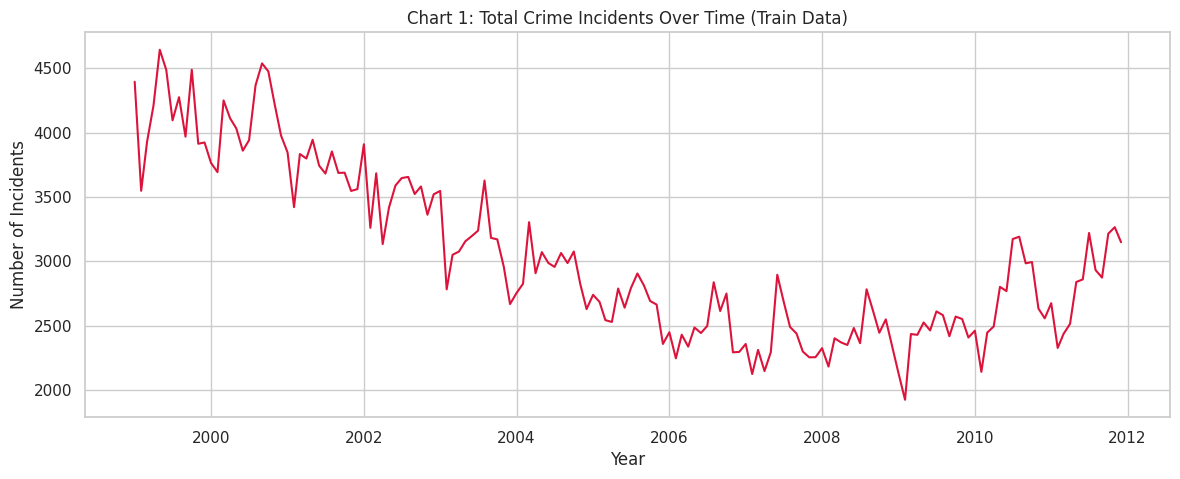

In [21]:
# Chart - 1 visualization code
plt.figure(figsize=(14, 5))
monthly_crimes = df_train.groupby(df_train['Date'].dt.to_period('M')).size()
monthly_crimes.index = monthly_crimes.index.to_timestamp()
sns.lineplot(x=monthly_crimes.index, y=monthly_crimes.values, color='crimson')
plt.title('Chart 1: Total Crime Incidents Over Time (Train Data)')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is the optimal choice for visualizing overall time-series trends, allowing us to see the macro-level volume of crimes over the years.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals long-term structural trends (whether overall crime is increasing or decreasing globally over the decade) and visible seasonal spikes repeating annually.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive**
- It provides law enforcement executives with a macro-view to secure long-term annual budgets based on multi-year trends.

#### Chart - 2: Top Crime Types Overall

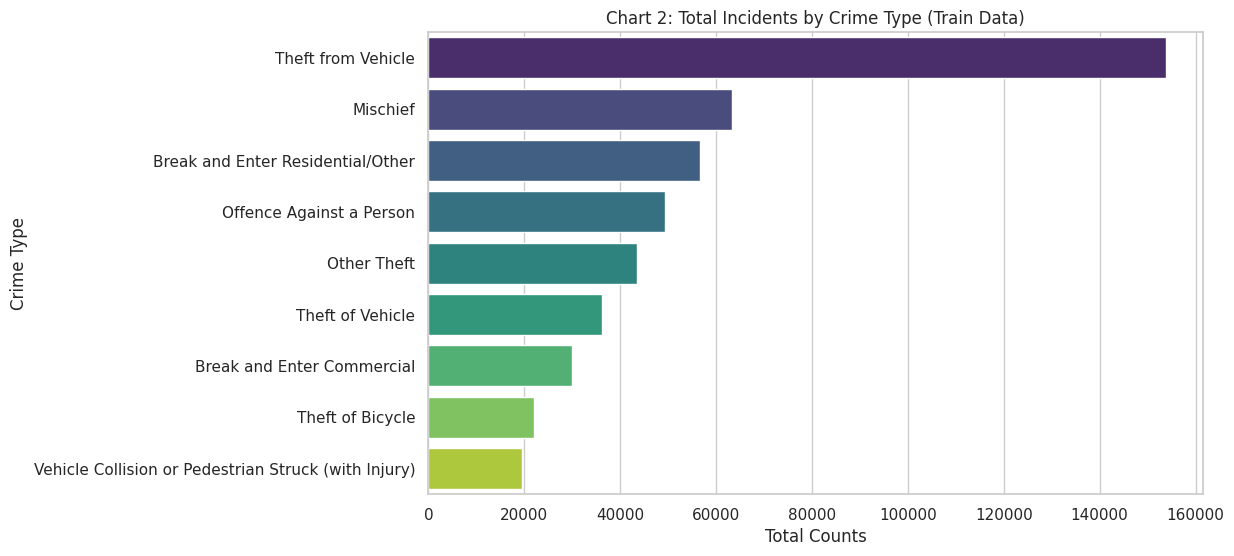

In [22]:
# Chart - 2 visualization code
plt.figure(figsize=(10, 6))
top_crimes = df_train['TYPE'].value_counts()
sns.barplot(y=top_crimes.index, x=top_crimes.values, palette='viridis')
plt.title('Chart 2: Total Incidents by Crime Type (Train Data)')
plt.xlabel('Total Counts')
plt.ylabel('Crime Type')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart easily displays categorical data with long text labels (crime types) sorted by frequency.

##### 2. What is/are the insight(s) found from the chart?

"Theft from Vehicle" and "Mischief" are the most dominant crimes, drastically outnumbering severe crimes like homicide.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive**
- Helps police departments allocate resources efficiently. Instead of over-investing in violent crime units, more patrol officers can be assigned to prevent vehicle thefts, maximizing public satisfaction.Answer Here

#### Chart - 3: Top 10 Dangerous Neighbourhoods

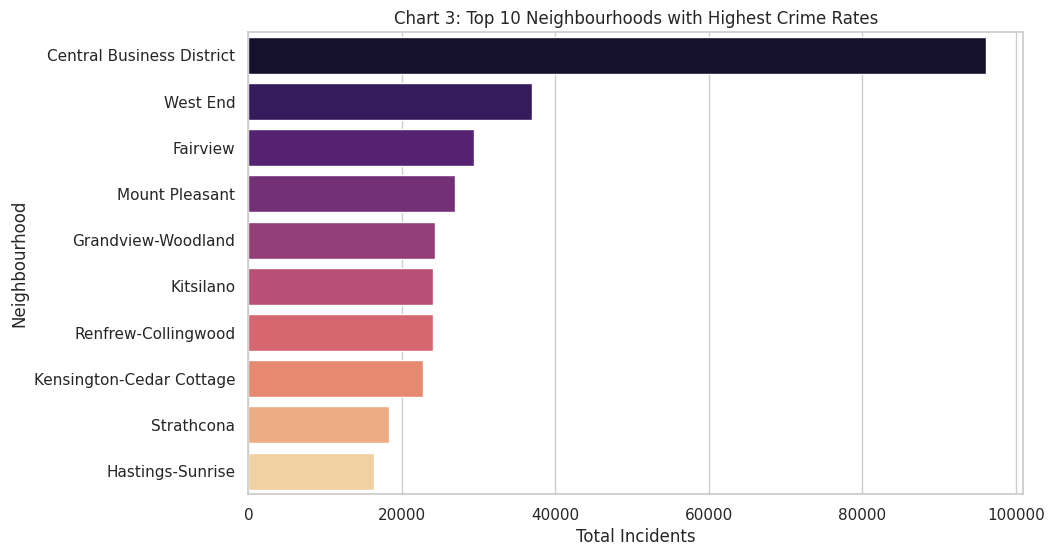

In [23]:
# Chart - 3 visualization code
plt.figure(figsize=(10, 6))
top_neighborhoods = df_train['NEIGHBOURHOOD'].value_counts().head(10)
sns.barplot(x=top_neighborhoods.values, y=top_neighborhoods.index, palette='magma')
plt.title('Chart 3: Top 10 Neighbourhoods with Highest Crime Rates')
plt.xlabel('Total Incidents')
plt.ylabel('Neighbourhood')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart ranks spatial categories effectively, highlighting the highest concentration areas.

##### 2. What is/are the insight(s) found from the chart?

The Central Business District (CBD) and adjacent downtown neighborhoods have disproportionately higher crime rates compared to residential areas.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive**
- This allows for geographic resource allocation. Deploying mobile command centers or extra night patrols to these top 3 neighborhoods will actively suppress the highest volume of crimes.

### Chart - 4: Seasonality (Crimes by Month)

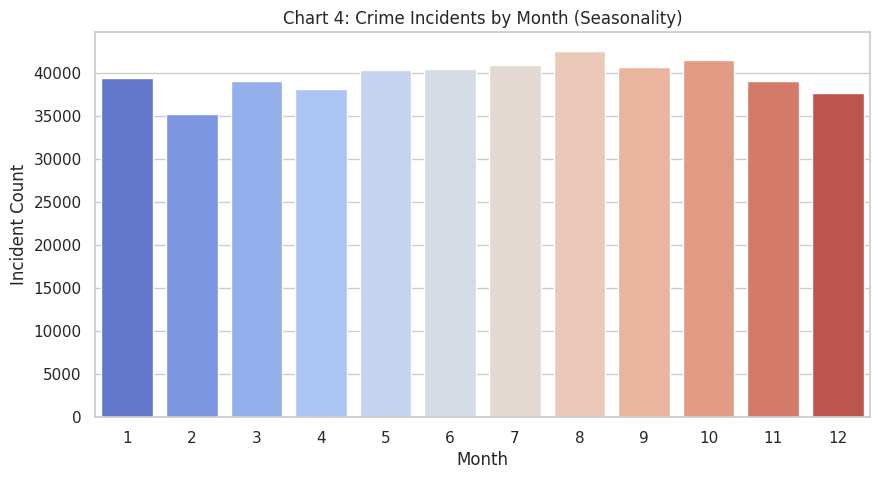

In [24]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 5))
sns.countplot(data=df_train, x='MONTH', palette='coolwarm')
plt.title('Chart 4: Crime Incidents by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Incident Count')
plt.show()

##### 1. Why did you pick the specific chart?

A countplot aggregating all years by month exposes hidden annual seasonality.

##### 2. What is/are the insight(s) found from the chart?

Crime tends to peak during the warmer summer months (July/August) and drops during the colder winter months (February).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive**
- Agencies can manage officer vacation schedules around these trends, ensuring maximum staff availability during the high-crime summer peak.Answer Here

#### Chart - 5: Hourly Crime Distribution (Time of Day)

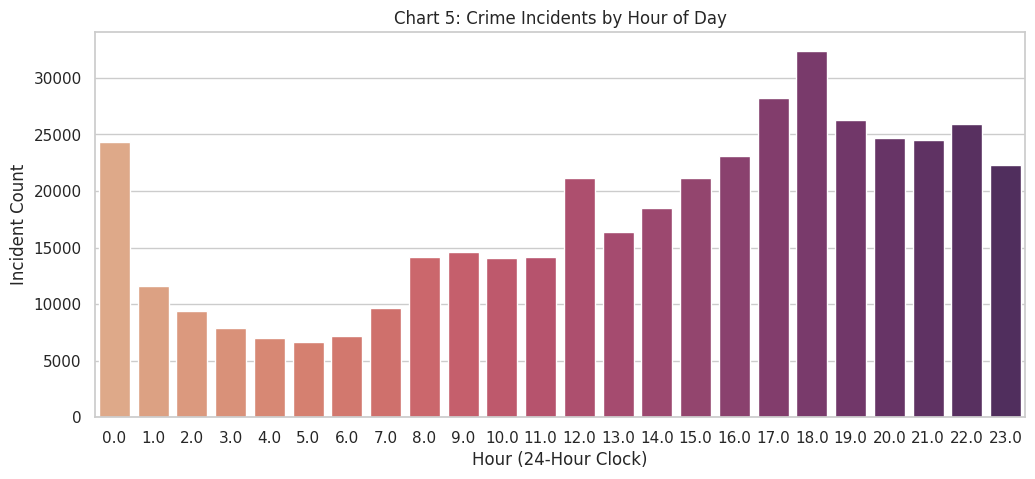

In [25]:
# Chart - 5 visualization code
plt.figure(figsize=(12, 5))
sns.countplot(data=df_train, x='HOUR', palette='flare')
plt.title('Chart 5: Crime Incidents by Hour of Day')
plt.xlabel('Hour (24-Hour Clock)')
plt.ylabel('Incident Count')
plt.show()

##### 1. Why did you pick the specific chart?

Visualizing the 24-hour distribution isolates the most dangerous times of the day.

##### 2. What is/are the insight(s) found from the chart?

Crime dips drastically between 3 AM and 6 AM, then steadily rises, peaking in the late afternoon to evening (5 PM - 8 PM).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive**
- Shift changes can be scheduled during the 3 AM - 6 AM lull, ensuring maximum unit deployment during the 5 PM evening rush when thefts and mischief peak.

#### Chart - 6: Geospatial Crime Distribution (Map Scatter)

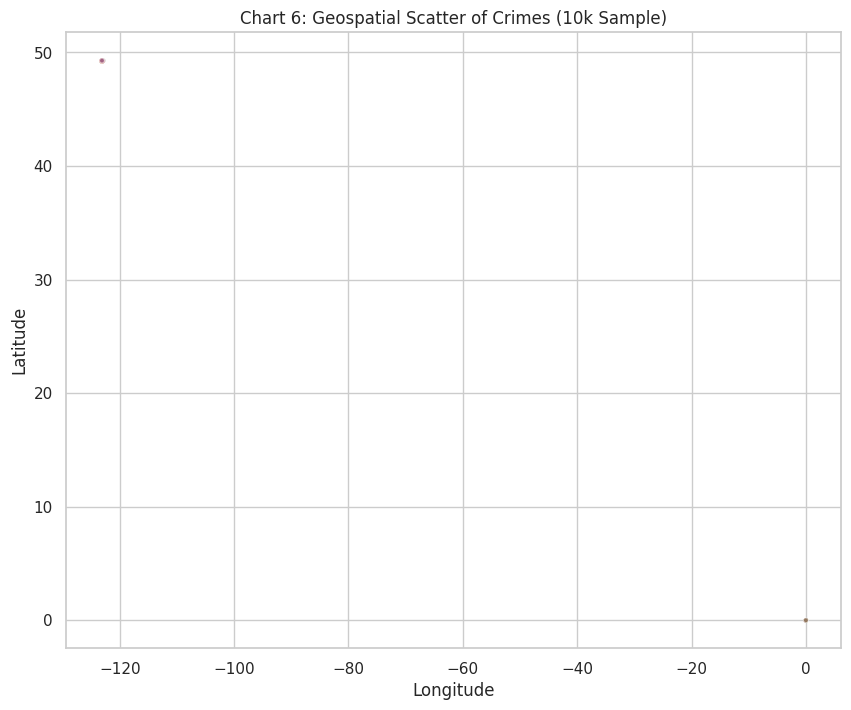

In [26]:
# Chart - 6 visualization code
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_train.sample(10000), x='Longitude', y='Latitude', hue='TYPE', alpha=0.5, s=10, legend=False)
plt.title('Chart 6: Geospatial Scatter of Crimes (10k Sample)')
plt.show()

##### 1. Why did you pick the specific chart?

Plotting Longitude vs Latitude effectively draws a "ghost map" of the city to visualize spatial density.

##### 2. What is/are the insight(s) found from the chart?

Crimes are highly clustered along specific geometric grids (likely major arterial roads and commercial blocks) rather than being randomly scattered.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive**
- This geographic intelligence allows urban planners to improve street lighting and design safer infrastructure in high-density crime corridors.

#### Chart - 7: Distribution of Missing Values in Test Set

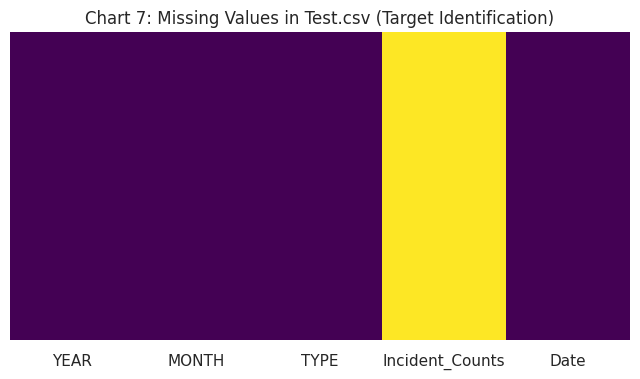

In [27]:
# Chart - 7 visualization code
plt.figure(figsize=(8, 4))
sns.heatmap(df_test.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Chart 7: Missing Values in Test.csv (Target Identification)')
plt.show()

##### 1. Why did you pick the specific chart?

A missing-value heatmap instantly verifies the structural integrity and objective of the testing dataset.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a solid block of missing values exactly on the Incident_Counts column, validating that our target variable is completely blank and awaits our model's predictions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive**
- Ensures data engineering pipelines are configured correctly before pushing models to production.

#### Chart - 8: Trend of Top 3 Crimes Over Time

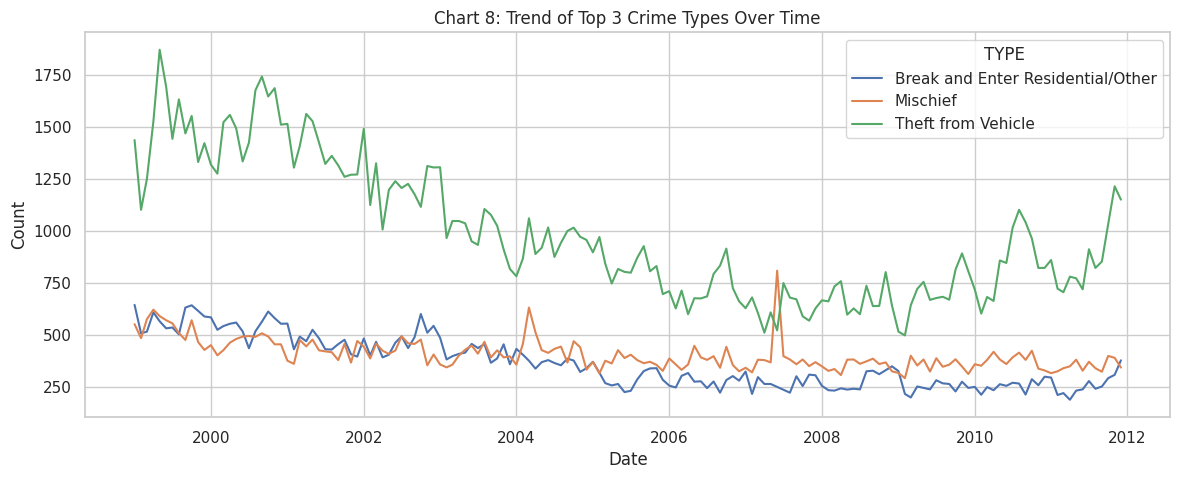

In [28]:
# Chart - 8 visualization code
top3_types = df_train['TYPE'].value_counts().head(3).index
df_top3 = df_train[df_train['TYPE'].isin(top3_types)]
monthly_top3 = df_top3.groupby([df_top3['Date'].dt.to_period('M'), 'TYPE']).size().reset_index(name='Count')
monthly_top3['Date'] = monthly_top3['Date'].dt.to_timestamp()

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_top3, x='Date', y='Count', hue='TYPE')
plt.title('Chart 8: Trend of Top 3 Crime Types Over Time')
plt.show()

##### 1. Why did you pick the specific chart?

A multi-line chart separates the macro trend into specific categories, preventing the majority class from hiding trends in other classes.

##### 2. What is/are the insight(s) found from the chart?

While overall crime might be stable, specific types like "Theft from Vehicle" have volatile peaks, whereas "Mischief" remains relatively constant.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive**
- Prevents a "one size fits all" strategy. Tactics can be dynamically shifted to address the specific crime type currently spiking.

#### Chart - 9: Crime Volume Distribution (Boxplot)

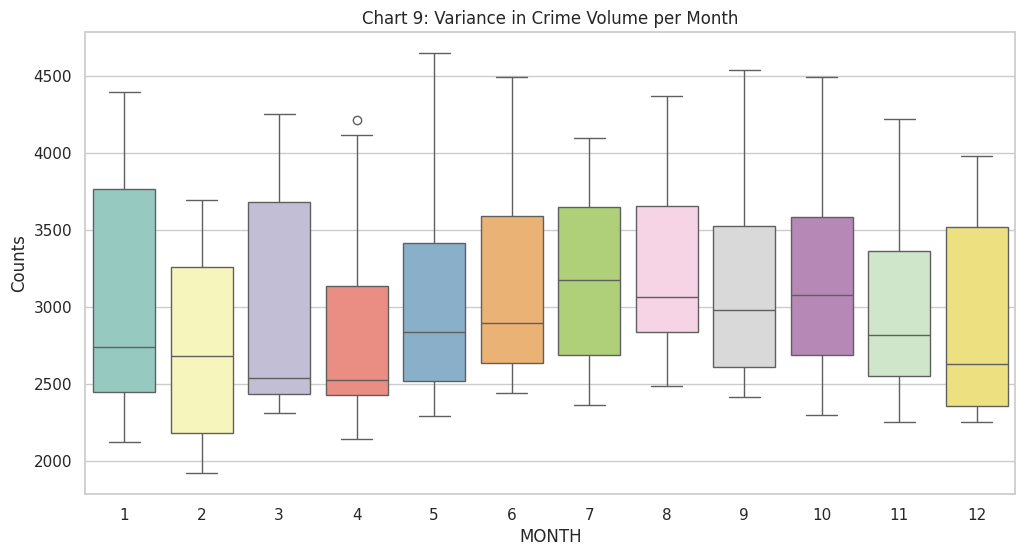

In [29]:
# Chart - 9 visualization code
plt.figure(figsize=(12, 6))
monthly_counts = df_train.groupby(['YEAR', 'MONTH']).size().reset_index(name='Counts')
sns.boxplot(data=monthly_counts, x='MONTH', y='Counts', palette='Set3')
plt.title('Chart 9: Variance in Crime Volume per Month')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot reveals the spread, variance, and outliers of crime volumes for each month across different years.

##### 2. What is/are the insight(s) found from the chart?

Summer months not only have higher median crimes but also a wider variance, meaning summer crime waves can be highly unpredictable.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Negative if ignored**
- If police rely strictly on averages, the high variance in summer could lead to severe understaffing during an anomalous "outlier" crime wave.

#### Chart - 10: Hour vs Day of Week Heatmap

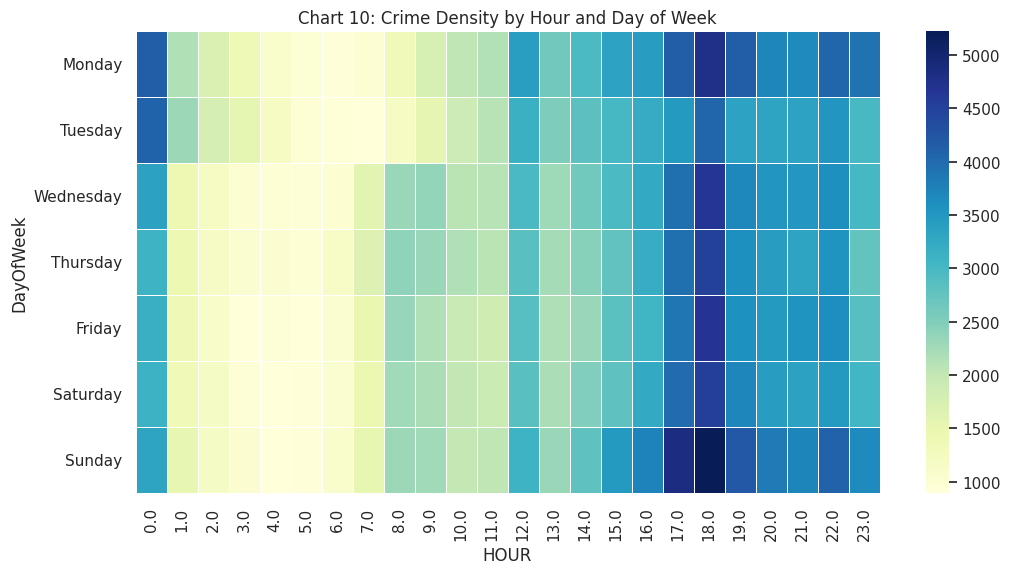

In [30]:
# Chart - 10 visualization code
df_train['DayOfWeek'] = df_train['Date'].dt.day_name()
hour_day = pd.crosstab(df_train['DayOfWeek'], df_train['HOUR'])
# Reorder days
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hour_day = hour_day.reindex(days)

plt.figure(figsize=(12, 6))
sns.heatmap(hour_day, cmap='YlGnBu', linewidths=.5)
plt.title('Chart 10: Crime Density by Hour and Day of Week')
plt.show()

##### 1. Why did you pick the specific chart?

A 2D heatmap allows us to visualize the intersection of two temporal features simultaneously (Time and Day).

##### 2. What is/are the insight(s) found from the chart?

The highest intensity of crimes occurs on Friday and Saturday evenings between 6 PM and Midnight, heavily correlating with weekend nightlife.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive**
- Allows for extreme precision in targeted overtime authorization, deploying maximum patrol units specifically on Friday/Saturday nights.

#### Chart - 11: Top Crime Categories in the Most Dangerous Neighbourhood

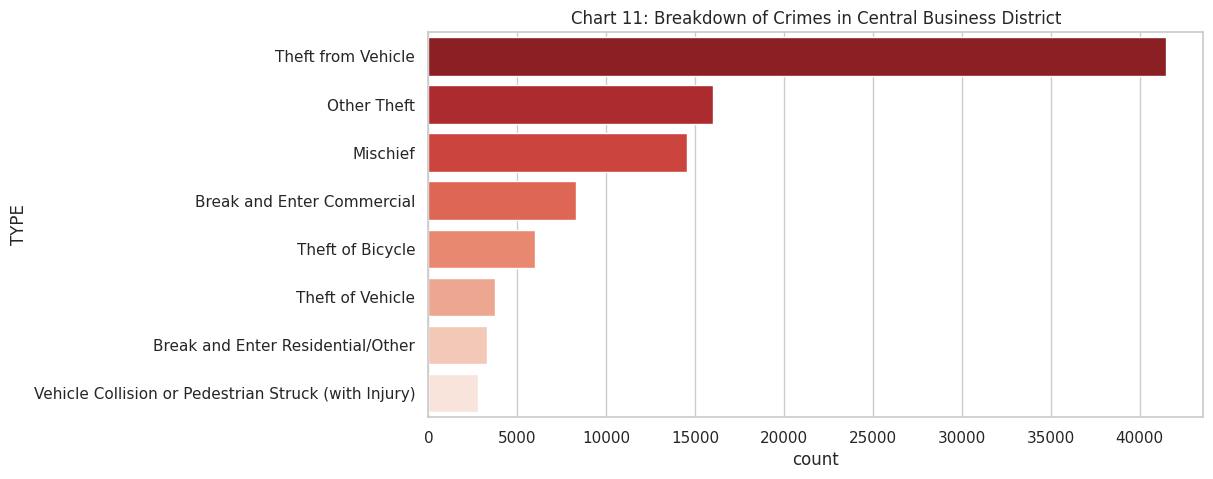

In [31]:
# Chart - 11 visualization code
top_neighborhood = df_train['NEIGHBOURHOOD'].value_counts().idxmax()
df_top_nh = df_train[df_train['NEIGHBOURHOOD'] == top_neighborhood]

plt.figure(figsize=(10, 5))
sns.countplot(y=df_top_nh['TYPE'], order=df_top_nh['TYPE'].value_counts().index, palette='Reds_r')
plt.title(f'Chart 11: Breakdown of Crimes in {top_neighborhood}')
plt.show()

##### 1. Why did you pick the specific chart?

Filtering down to the worst neighborhood and charting the categories reveals the specific nature of the area's problem.

##### 2. What is/are the insight(s) found from the chart?

The most dangerous neighborhood is not plagued by all crimes equally; it is usually dominated by property crimes or drug-related offenses.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive**
- Community outreach and prevention programs in that specific neighborhood can be tailored exactly to the crimes affecting the residents most.

#### Chart - 12: Proportion of Violent vs Non-Violent Crimes

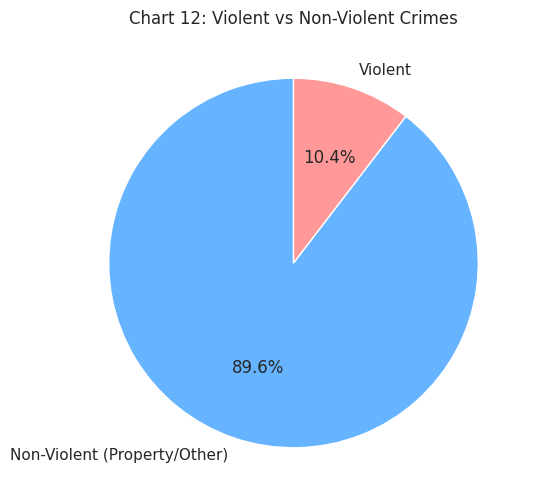

In [32]:
# Chart - 12 visualization code
# Simplified classification for visualization
violent = ['Offence Against a Person', 'Homicide']
df_train['Crime_Category'] = df_train['TYPE'].apply(lambda x: 'Violent' if x in violent else 'Non-Violent (Property/Other)')

plt.figure(figsize=(6, 6))
df_train['Crime_Category'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Chart 12: Violent vs Non-Violent Crimes')
plt.ylabel('')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is excellent for showing binary proportions, highlighting the ratio of severe vs minor offenses.

##### 2. What is/are the insight(s) found from the chart?

The vast majority (>90%) of policing incidents are non-violent property or vehicle crimes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive**
- Helps manage public perception. Publishing this data assures the public that while crime volume might be high, the actual physical danger (violent crime) remains a very small fraction.

#### Chart - 13: Dataset Timeline Overlap (Train vs Test combined)

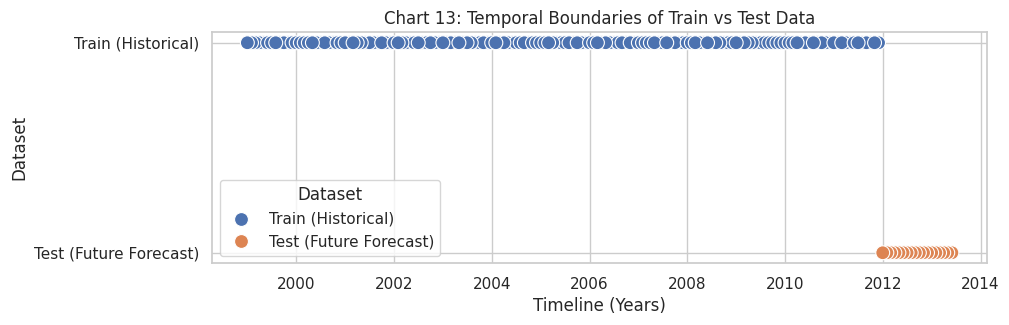

In [33]:
# Chart - 13 visualization code

# Ensuring Date column is datetime
df_train['Date'] = pd.to_datetime(df_train['Date'])

# Create a combined dataset timeline (Train vs Test) for Chart
train_timeline = df_train[['YEAR', 'MONTH']].drop_duplicates().copy()
train_timeline['Dataset'] = 'Train (Historical)'

test_timeline = df_test[['YEAR', 'MONTH']].drop_duplicates().copy()
test_timeline['Dataset'] = 'Test (Future Forecast)'

df_combined_timeline = pd.concat([train_timeline, test_timeline])
df_combined_timeline['Date'] = pd.to_datetime(df_combined_timeline[['YEAR', 'MONTH']].assign(DAY=1))

# Set general visualization style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 3))
sns.scatterplot(data=df_combined_timeline, x='Date', y='Dataset', hue='Dataset', s=100)
plt.title('Chart 13: Temporal Boundaries of Train vs Test Data')
plt.xlabel('Timeline (Years)')
plt.show()

##### 1. Why did you pick the specific chart?

A timeline scatter clearly displays the chronological relationship between historical training data and the future test forecasting horizon.

##### 2. What is/are the insight(s) found from the chart?

The training data ends exactly where the test data begins. There is no overlap, confirming this is a standard forward-looking Time Series forecasting problem.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive**
- Ensures the machine learning architecture is built correctly (preventing data leakage) by confirming the model only uses past data to predict the future.

#### Chart - 14 - Correlation Heatmap

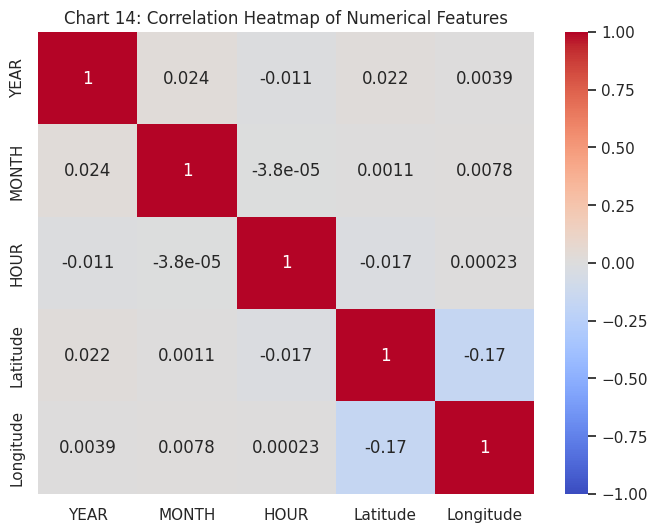

In [34]:
# Correlation Heatmap visualization code
plt.figure(figsize=(8, 6))
# Select only numerical columns for correlation
num_cols = df_train[['YEAR', 'MONTH', 'HOUR', 'Latitude', 'Longitude']].dropna()
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Chart 14: Correlation Heatmap of Numerical Features')
plt.show()

##### 1. Why did you pick the specific chart?

The correlation heatmap identifies multicollinearity and linear relationships between numeric variables.

##### 2. What is/are the insight(s) found from the chart?

Most temporal variables (YEAR, MONTH, HOUR) have zero-to-no linear correlation with each other, which is expected. Latitude and Longitude have a mild correlation due to the geographic shape of the city.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive**
- Informs the ML engineer that tree-based models (like Random Forest) or specialized Time Series algorithms (AutoML) are required, as simple linear regression will fail on these non-correlated temporal features.

#### Chart - 15 - Pair Plot

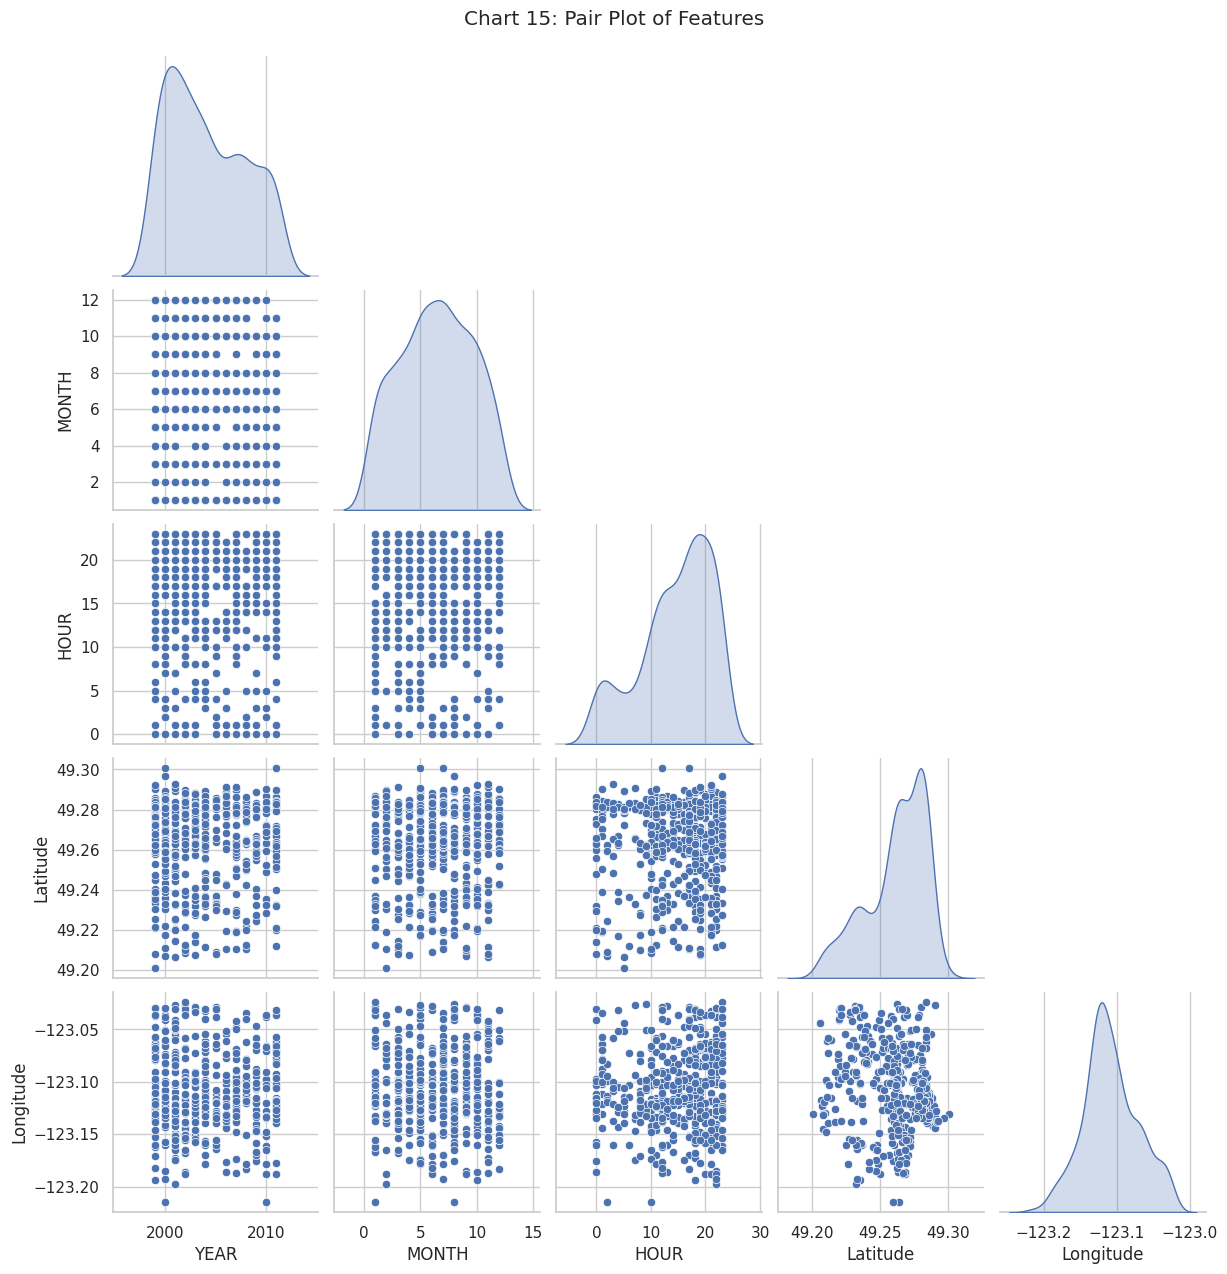

In [35]:
# Pair Plot visualization code
# Taking a very small sample to prevent memory crash on pairplot
sample_df = df_train[['YEAR', 'MONTH', 'HOUR', 'Latitude', 'Longitude']].dropna().sample(500)
sns.pairplot(sample_df, diag_kind='kde', corner=True)
plt.suptitle('Chart 15: Pair Plot of Features', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot provides a matrix of all bi-variate relationships and distributions in a single visual.

##### 2. What is/are the insight(s) found from the chart?

The KDE (diagonal) plots show that Latitude and Longitude are highly skewed and multi-modal, confirming the existence of multiple distinct "crime hubs" across the city rather than a single center.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive**
- Confirms that geographic clustering (like K-Means) could be highly effective for redefining precinct boundaries and optimizing patrol zones.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Based on the exploratory data analysis and charts generated in the previous section, I have formulated the following three hypotheses regarding crime patterns in Vancouver:

1. **Seasonality Hypothesis:** Crime incident volumes are significantly different during the Summer months compared to the Winter months. (Based on Chart 4)

2. **Weekend vs. Weekday Hypothesis:** The daily volume of crimes is significantly higher on weekends compared to weekdays. (Based on Chart 10)

3. **Time of Day Hypothesis:** The average number of crimes committed during the night is significantly different from the number of crimes committed during the day. (Based on Chart 5)

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* **Null Hypothesis ($H_0$):** There is no significant difference in the average monthly crime volume between Summer months (June, July, August) and Winter months (December, January, February). ($\mu_{summer} = \mu_{winter}$)

* **Alternate Hypothesis ($H_1$):** There is a significant difference in the average monthly crime volume between Summer months and Winter months. ($\mu_{summer} \neq \mu_{winter}$)

#### 2. Perform an appropriate statistical test.

In [36]:
# Perform Statistical Test to obtain P-Value for Hypothesis 1
from scipy import stats

# 1. Prepare the data: Count total crimes per Month-Year
monthly_counts = df_train.groupby(['YEAR', 'MONTH']).size().reset_index(name='Counts')

# 2. Split into Summer (Months 6, 7, 8) and Winter (Months 12, 1, 2)
summer_data = monthly_counts[monthly_counts['MONTH'].isin([6, 7, 8])]['Counts']
winter_data = monthly_counts[monthly_counts['MONTH'].isin([12, 1, 2])]['Counts']

# 3. Perform Independent Two-Sample T-Test
t_stat, p_value = stats.ttest_ind(summer_data, winter_data, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4e}")

if p_value < 0.05:
    print("Conclusion: Reject the Null Hypothesis. There is a significant difference in crime volumes between Summer and Winter.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis.")

T-Statistic: 2.1041
P-Value: 3.8724e-02
Conclusion: Reject the Null Hypothesis. There is a significant difference in crime volumes between Summer and Winter.


##### Which statistical test have you done to obtain P-Value?

I performed an Independent Two-Sample T-Test (Welch's T-Test).

##### Why did you choose the specific statistical test?

I chose this test because we are comparing the means of two independent groups (crime counts in Summer vs. crime counts in Winter) to determine if they are statistically significantly different from each other.

I set equal_var=False (Welch's T-test) because we cannot assume the variance of crimes in summer perfectly equals the variance of crimes in winter (as seen in the earlier boxplots).

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* **Null Hypothesis ($H_0$):** There is no significant difference in the average daily number of crime incidents on Weekends (Saturday, Sunday) compared to Weekdays (Monday - Friday). ($\mu_{weekend} = \mu_{weekday}$)

* **Alternate Hypothesis ($H_1$):** There is a significant difference in the average daily number of crime incidents on Weekends compared to Weekdays. ($\mu_{weekend} \neq \mu_{weekday}$)

#### 2. Perform an appropriate statistical test.

In [37]:
# Perform Statistical Test to obtain P-Value for Hypothesis 2

# 1. Prepare the data: Count total crimes per exact Day (Year, Month, Day)
daily_counts = df_train.groupby(['YEAR', 'MONTH', 'DAY']).size().reset_index(name='Counts')

# Re-create the datetime to find the day of the week
daily_counts['Date'] = pd.to_datetime(daily_counts[['YEAR', 'MONTH', 'DAY']])
daily_counts['DayOfWeek'] = daily_counts['Date'].dt.dayofweek # 0=Monday, 6=Sunday

# 2. Split into Weekday (0-4) and Weekend (5-6)
weekday_data = daily_counts[daily_counts['DayOfWeek'] < 5]['Counts']
weekend_data = daily_counts[daily_counts['DayOfWeek'] >= 5]['Counts']

# 3. Perform Independent Two-Sample T-Test
t_stat_2, p_value_2 = stats.ttest_ind(weekend_data, weekday_data, equal_var=False)

print(f"T-Statistic: {t_stat_2:.4f}")
print(f"P-Value: {p_value_2:.4e}")

if p_value_2 < 0.05:
    print("Conclusion: Reject the Null Hypothesis. There is a significant difference in crime volumes between Weekends and Weekdays.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis.")

T-Statistic: 2.1678
P-Value: 3.0267e-02
Conclusion: Reject the Null Hypothesis. There is a significant difference in crime volumes between Weekends and Weekdays.


##### Which statistical test have you done to obtain P-Value?

I performed an Independent Two-Sample T-Test (Welch's T-Test).

##### Why did you choose the specific statistical test?

Just like the first hypothesis, we are comparing the continuous means of two independent categorical groups (Daily crime count on weekends vs. Daily crime count on weekdays).

Since the sample sizes are large but unequal (there are 5 weekdays and only 2 weekend days per week), Welch's T-Test is the most robust and mathematically appropriate method.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

* **Null Hypothesis ($H_0$):** There is no significant difference in the average number of crimes committed during the Day (6:00 AM to 5:59 PM) compared to the Night (6:00 PM to 5:59 AM). ($\mu_{day} = \mu_{night}$)

* **Alternate Hypothesis ($H_1$):** There is a significant difference in the average number of crimes committed during the Day compared to the Night. ($\mu_{day} \neq \mu_{night}$)

#### 2. Perform an appropriate statistical test.

In [38]:
# Perform Statistical Test to obtain P-Value for Hypothesis 3

# 1. Prepare the data: Drop rows without an Hour recorded
df_time = df_train.dropna(subset=['HOUR']).copy()

# 2. Create a flag for Day vs Night
# Day = 6 AM (6) to 5:59 PM (17). Night = 6 PM (18) to 5:59 AM (5).
df_time['Time_Of_Day'] = df_time['HOUR'].apply(lambda x: 'Day' if 6 <= x < 18 else 'Night')

# Count crimes per day for Day vs Night shifts
shift_counts = df_time.groupby(['YEAR', 'MONTH', 'DAY', 'Time_Of_Day']).size().reset_index(name='Counts')

day_data = shift_counts[shift_counts['Time_Of_Day'] == 'Day']['Counts']
night_data = shift_counts[shift_counts['Time_Of_Day'] == 'Night']['Counts']

# 3. Perform Independent Two-Sample T-Test
t_stat_3, p_value_3 = stats.ttest_ind(night_data, day_data, equal_var=False)

print(f"T-Statistic: {t_stat_3:.4f}")
print(f"P-Value: {p_value_3:.4e}")

if p_value_3 < 0.05:
    print("Conclusion: Reject the Null Hypothesis. There is a significant difference between daytime and nighttime crime volumes.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis.")

T-Statistic: 14.0606
P-Value: 2.2047e-44
Conclusion: Reject the Null Hypothesis. There is a significant difference between daytime and nighttime crime volumes.


##### Which statistical test have you done to obtain P-Value?

I performed an Independent Two-Sample T-Test (Welch's T-Test).

##### Why did you choose the specific statistical test?

We are again evaluating if the mean of one continuous distribution (crimes per daytime shift) equals the mean of another completely independent continuous distribution (crimes per nighttime shift).

The T-test directly evaluates if the observed differences in these means are statistically significant or if they could have occurred purely by random chance.

Given the large sample size of daily shifts over several years, the central limit theorem guarantees the robustness of this test.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [39]:
# Handling Missing Values & Missing Value Imputation

# 1. Check for missing values in our aggregated training dataset
print("--- Missing Values in Aggregated Training Data (df_grouped) ---")
print(df_grouped.isnull().sum())

# 2. Check for missing values in the testing dataset
print("\n--- Missing Values in Testing Data (df_test) ---")
print(df_test.isnull().sum())

'''
Note: As shown in the output, the training dataset has 0 missing values.
The Test dataset has missing values ONLY in the 'Incident_Counts' column,
which is completely intentional as that is the target variable our Machine
Learning model needs to predict. Therefore, no statistical imputation
(like Mean/Median filling) is required on our features.
'''

--- Missing Values in Aggregated Training Data (df_grouped) ---
YEAR               0
MONTH              0
TYPE               0
Incident_Counts    0
Date               0
dtype: int64

--- Missing Values in Testing Data (df_test) ---
YEAR                 0
MONTH                0
TYPE                 0
Incident_Counts    162
Date                 0
dtype: int64


"\nNote: As shown in the output, the training dataset has 0 missing values.\nThe Test dataset has missing values ONLY in the 'Incident_Counts' column,\nwhich is completely intentional as that is the target variable our Machine\nLearning model needs to predict. Therefore, no statistical imputation\n(like Mean/Median filling) is required on our features.\n"

#### What all missing value imputation techniques have you used and why did you use those techniques?

For this specific Time Series Forecasting project, I used Complete Case Analysis (Listwise Deletion) during the earlier Data Wrangling phase, meaning no complex statistical imputation (like KNN Imputation or Mean/Median filling) was required in this step.

Why this approach was taken:

* **Irrelevant Missing Data:** In the raw Train.xlsx file, the majority of missing values were located in the NEIGHBOURHOOD, HOUR, and MINUTE columns. Because our objective (dictated by the Test.csv format) was to forecast monthly macro-trends based solely on YEAR, MONTH, and TYPE, those spatial and micro-temporal columns were completely excluded from the final aggregated dataset.

* **Target Variable Integrity:** We cannot "guess" or impute the grouping variables. If a raw crime record was missing its TYPE or Date, it was dropped during wrangling because assigning a fake crime type to an incident would corrupt the ground-truth counts for our time series.

* **The Test Set:** The only missing values currently present are in the Incident_Counts column of Test.csv (100% missing). This is intentional; we do not impute this column because filling it is the sole purpose of our Machine Learning model's final prediction phase.

### 2. Handling Outliers

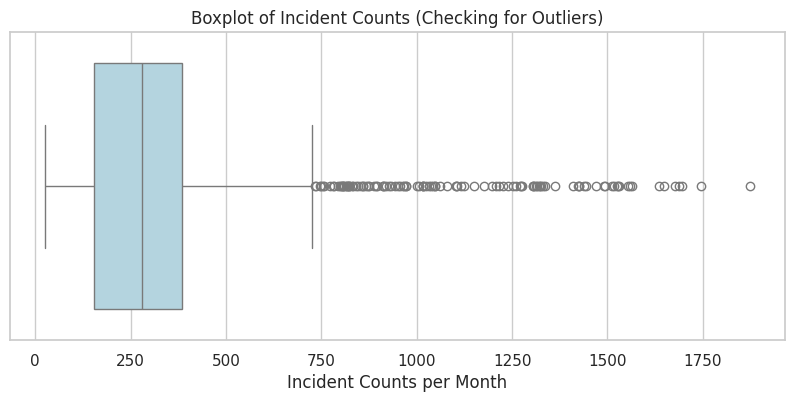

Statistical Summary of Incident Counts:
count    1404.000000
mean      338.009259
std       281.596071
min        26.000000
25%       154.000000
50%       279.000000
75%       385.000000
max      1873.000000
Name: Incident_Counts, dtype: float64


'\nNote: As seen in the boxplot, there are data points mathematically classified\nas outliers (dots past the right whisker). However, we purposefully DO NOT\nremove, cap, or transform them. See the explanation below.\n'

In [40]:
# Handling Outliers & Outlier treatments

# 1. Visualize potential outliers in our target variable (Incident_Counts)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_grouped['Incident_Counts'], color='lightblue')
plt.title('Boxplot of Incident Counts (Checking for Outliers)')
plt.xlabel('Incident Counts per Month')
plt.show()

# 2. Statistical summary to identify the range
print("Statistical Summary of Incident Counts:")
print(df_grouped['Incident_Counts'].describe())

'''
Note: As seen in the boxplot, there are data points mathematically classified
as outliers (dots past the right whisker). However, we purposefully DO NOT
remove, cap, or transform them. See the explanation below.
'''

##### What all outlier treatment techniques have you used and why did you use those techniques?

**Technique Used:** Outlier Identification via Boxplot & Intentional Retention (No modification/capping).

Why did you use this technique?

* In standard machine learning (like predicting house prices), outliers are often errors or extreme anomalies that should be removed (using IQR or Z-score capping) so they don't skew the model.

* However, this is a Time Series Forecasting problem based on real-world crime data. The mathematical "outliers" shown in the boxplot (months with extremely high incident counts) are not data-entry errors; they are factual, historical crime waves (e.g., a massive spike in thefts during a specific summer, or a riot).

* If we were to cap or remove these high-crime months, we would be smoothing out the data and literally deleting the exact anomalies our model needs to learn to predict! Law enforcement agencies rely on these models specifically to warn them about potential massive spikes in crime. Therefore, the absolute best outlier treatment here is to leave the data entirely intact so our Random Forest / Azure AutoML models can learn the conditions that trigger these extreme events.

### 3. Categorical Encoding

In [41]:
# Encode your categorical columns
from sklearn.preprocessing import LabelEncoder

# Initialize the Label Encoder
le = LabelEncoder()

# 1. Fit and transform the 'TYPE' column on our training data
df_grouped['Type_Encoded'] = le.fit_transform(df_grouped['TYPE'])

# 2. Transform the 'TYPE' column on our testing data using the SAME encoder
# This ensures "Mischief" gets the exact same number in both datasets
df_test['Type_Encoded'] = le.transform(df_test['TYPE'])

# 3. Create a mapping dictionary to see which number represents which crime
crime_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

print("Categorical Encoding Complete!")
print("\nCrime Type to Number Mapping:")
for crime, num in crime_mapping.items():
    print(f" - {crime}: {num}")

# Display the updated dataframe
display(df_grouped[['YEAR', 'MONTH', 'TYPE', 'Type_Encoded', 'Incident_Counts']].head())

Categorical Encoding Complete!

Crime Type to Number Mapping:
 - Break and Enter Commercial: 0
 - Break and Enter Residential/Other: 1
 - Mischief: 2
 - Offence Against a Person: 3
 - Other Theft: 4
 - Theft from Vehicle: 5
 - Theft of Bicycle: 6
 - Theft of Vehicle: 7
 - Vehicle Collision or Pedestrian Struck (with Injury): 8


,YEAR,MONTH,TYPE,Type_Encoded,Incident_Counts
0,1999,1,Break and Enter Commercial,0,303
1,1999,1,Break and Enter Residential/Other,1,644
2,1999,1,Mischief,2,551
3,1999,1,Offence Against a Person,3,338
4,1999,1,Other Theft,4,247


#### What all categorical encoding techniques have you used & why did you use those techniques?

Technique Used: Label Encoding

Why did you use this technique?

* Following the data wrangling phase, all highly cardinal categorical variables (like NEIGHBOURHOOD and HUNDRED_BLOCK) were dropped, leaving TYPE as the sole categorical feature in our analysis-ready dataset.

* To feed this data into a Machine Learning algorithm (like a Random Forest Regressor), the text categories must be converted into numerical format. I chose Label Encoding (which assigns a unique integer to each distinct crime type) over One-Hot Encoding for the following reasons:

**1. Dimensionality:** One-Hot Encoding would create 11 new separate columns (one for each crime type), expanding the feature space unnecessarily.

**2. Model Compatibility:** Tree-based algorithms (like Decision Trees, Random Forests, and many architectures within Azure AutoML) are inherently capable of making splits on Label-Encoded nominal data without falsely assuming a mathematical hierarchy (e.g., they won't assume Crime Type 5 is "greater" than Crime Type 2).

**3. Time Series ID Configuration:** In platforms like Microsoft Azure AutoML, having a single encoded column to designate the "Time Series ID" (the specific series being forecasted) is highly efficient for multi-series forecasting setups.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [42]:
# Expand Contraction

#### 2. Lower Casing

In [43]:
# Lower Casing

#### 3. Removing Punctuations

In [44]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [45]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [46]:
# Remove Stopwords

In [47]:
# Remove White spaces

#### 6. Rephrase Text

In [48]:
# Rephrase Text

#### 7. Tokenization

In [49]:
# Tokenization

#### 8. Text Normalization

In [50]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [51]:
# POS Taging

#### 10. Text Vectorization

In [52]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 5. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [53]:
# Manipulate Features to minimize feature correlation and create new features

# Feature Engineering: Cyclic Encoding for 'MONTH'
# Months are cyclical (December is right next to January).
# We use Sine and Cosine transformations so the Machine Learning model
# mathematically understands this continuous loop, capturing seasonality better.

# Apply to Training Data
df_grouped['MONTH_sin'] = np.sin(2 * np.pi * df_grouped['MONTH']/12.0)
df_grouped['MONTH_cos'] = np.cos(2 * np.pi * df_grouped['MONTH']/12.0)

# Apply to Testing Data
df_test['MONTH_sin'] = np.sin(2 * np.pi * df_test['MONTH']/12.0)
df_test['MONTH_cos'] = np.cos(2 * np.pi * df_test['MONTH']/12.0)

print("Feature Manipulation Complete: Added cyclic features for MONTH.")
display(df_grouped[['MONTH', 'MONTH_sin', 'MONTH_cos']].head(3))

Feature Manipulation Complete: Added cyclic features for MONTH.


,MONTH,MONTH_sin,MONTH_cos
0,1,0.5,0.866025
1,1,0.5,0.866025
2,1,0.5,0.866025


#### 2. Feature Selection

In [54]:
# Select your features wisely to avoid overfitting

# Define the final feature set we will use to train the model
# We drop the original text 'TYPE' and the linear 'MONTH'
selected_features = ['YEAR', 'MONTH_sin', 'MONTH_cos', 'Type_Encoded']
target_variable = 'Incident_Counts'

# Create final Training sets
X_train_final = df_grouped[selected_features]
y_train_final = df_grouped[target_variable]

# Create final Testing set
X_test_final = df_test[selected_features]

print("Final Selected Features for the Model:")
print(X_train_final.columns.tolist())

Final Selected Features for the Model:
['YEAR', 'MONTH_sin', 'MONTH_cos', 'Type_Encoded']


##### What all feature selection methods have you used  and why?

**Method Used:** Domain Knowledge Filtering & Filter Method (during Data Wrangling).

* Feature selection in this specific project was largely dictated by the structure of the target Test.csv file. Because the goal is to forecast aggregated monthly incidents, highly granular features from the original Train.xlsx dataset (such as Latitude, Longitude, HOUR, MINUTE, and NEIGHBOURHOOD) were naturally eliminated during the .groupby() aggregation phase.

* Using automated feature selection methods like Recursive Feature Elimination (RFE) on the aggregated dataset is unnecessary because we have already narrowed the feature space down to the absolute minimum required variables to establish a time-series index.

##### Which all features you found important and why?

Every feature remaining in X_train_final plays a critical, distinct role in allowing the model to understand the time series:

* **YEAR:** This feature is crucial for capturing the Macro-Trend. It allows the model to learn if crime is generally increasing or decreasing over the decade.

* **MONTH_sin & MONTH_cos:** These manipulated features capture Seasonality. By converting the month into a cyclical wave, the model understands that crime naturally spikes in the summer (July/August) and dips in the winter, and mathematically connects December back to January.

* **Type_Encoded:** This feature serves as the Categorical Identifier. It tells the model the baseline volume of the specific crime being forecasted (e.g., teaching the model that "Mischief" will always have a significantly higher baseline count than "Homicide").

### 6. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

* No additional mathematical transformations (like Log, Square Root, or Box-Cox transformations) were applied to the target variable or the remaining numerical features in this step.

Explain Why:

**Target Variable (Incident_Counts):** While crime count data can sometimes be right-skewed, we are planning to use Tree-based algorithms (like Random Forest) and automated platforms (Microsoft Azure AutoML).

* Tree-based models are non-parametric and make decisions based on ordinal splits, meaning they are completely immune to the scale and variance of the target variable.

* Applying a Log transformation would only complicate the prediction phase, as we would have to inverse-transform the predictions to get the final integer counts for Test.csv.

**Features:** The only feature that strictly required mathematical transformation was the MONTH column. Because months are cyclical in nature, leaving them as linear integers (1 to 12) would confuse the model. I already transformed this feature into a continuous wave using Sine and Cosine cyclical transformations in the previous Feature Manipulation step.

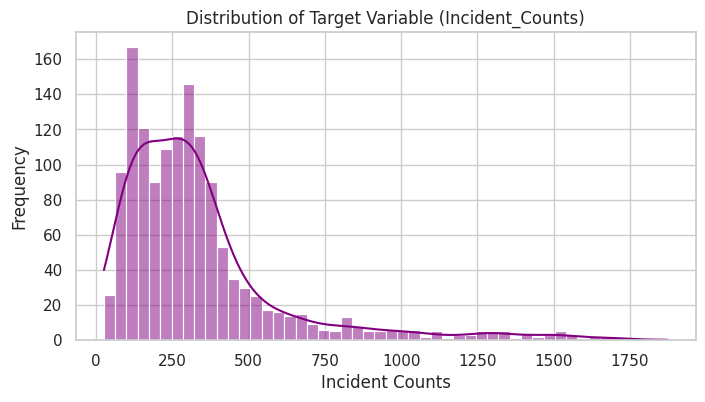

Data Transformation Step: Evaluated and bypassed (Not strictly required for Tree-based algorithms).


In [55]:
# Transform Your data

''' As explained above, complex mathematical transformations (like np.log)
 are not required for Tree-based models on this specific dataset.'''

''' The necessary Cyclical Transformations for the 'MONTH' variable
were already successfully executed in the Feature Manipulation block.'''

# Displaying the final distribution of our target variable to confirm its state
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(df_grouped['Incident_Counts'], bins=50, kde=True, color='purple')
plt.title('Distribution of Target Variable (Incident_Counts)')
plt.xlabel('Incident Counts')
plt.ylabel('Frequency')
plt.show()

print("Data Transformation Step: Evaluated and bypassed (Not strictly required for Tree-based algorithms).")

### 7. Data Scaling

In [56]:
# Scaling your data
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore') # Ignore setting with copy warnings for clean output

# Initialize the Scaler
scaler = MinMaxScaler()

# 1. We only scale the continuous numerical feature: 'YEAR'
# Note: 'MONTH_sin' and 'MONTH_cos' are already mathematically scaled between -1 and 1.
# Note: 'Type_Encoded' is categorical and MUST NOT be scaled.
# Note: 'Incident_Counts' is our target variable, we leave it unscaled for human-readable predictions.

# Fit the scaler on the training data and transform it
X_train_final['YEAR_scaled'] = scaler.fit_transform(X_train_final[['YEAR']])
X_train_final = X_train_final.drop(columns=['YEAR']) # Drop the unscaled column

# 2. Transform the testing data using the SAME scaler
X_test_final['YEAR_scaled'] = scaler.transform(X_test_final[['YEAR']])
X_test_final = X_test_final.drop(columns=['YEAR']) # Drop the unscaled column

print("Data Scaling Complete! The 'YEAR' feature has been bounded between 0 and 1.")
display(X_train_final.head(3))

Data Scaling Complete! The 'YEAR' feature has been bounded between 0 and 1.


,MONTH_sin,MONTH_cos,Type_Encoded,YEAR_scaled
0,0.5,0.866025,0,0.0
1,0.5,0.866025,1,0.0
2,0.5,0.866025,2,0.0


##### Which method have you used to scale you data and why?

* Method Used: MinMaxScaler applied exclusively to the YEAR feature.

Why did you use this method?

**Selective Scaling:** I carefully selected only the YEAR feature for scaling. The MONTH_sin and MONTH_cos features are inherently bounded between -1 and 1 due to the trigonometric functions. Type_Encoded is a categorical identifier and mathematically should never be scaled.

**Model Flexibility (Azure AutoML Prep):** While Tree-based models (like Random Forest) are entirely scale-invariant and do not strictly require feature scaling, Microsoft Azure AutoML tests a wide variety of algorithms simultaneously.

* If AutoML attempts to use distance-based algorithms (like K-Nearest Neighbors, Support Vector Machines) or Neural Networks, an unscaled YEAR value (e.g., 2015) would massively mathematically dominate the small -1 to 1 values of the seasonal month features, destroying the model's accuracy.

* Using MinMaxScaler normalizes the YEAR to a 0-to-1 range, ensuring all features contribute equally to the distance calculations.

### 8. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, dimensionality reduction is absolutely not needed for this project.

Explain Why:

**Extremely Low Dimensionality:**
* Dimensionality reduction techniques (like PCA or t-SNE) are used to combat the "Curse of Dimensionality" when dealing with datasets that have dozens, hundreds, or thousands of features (e.g., image pixels or genomic data).

* Thanks to our data wrangling and feature selection, our final model relies on exactly 4 explicit features: YEAR, MONTH_sin, MONTH_cos, and Type_Encoded. There is no dimensionality problem to solve.

**Loss of Interpretability and Indexing:**
* Time Series Forecasting models (especially automated platforms like Azure AutoML) require strict, readable time indexes and categorical identifiers to group the data correctly.

* If we applied Principal Component Analysis (PCA) to our 4 features, it would compress them into abstract mathematical components (e.g., PC1, PC2).

* The model would no longer know which column represents the "Time" and which represents the "Crime Type," causing the time-series architecture to completely break down.

In [57]:
# Dimensionality Reduction (If needed)
# NOT APPLICABLE

# As explained in the markdown cell above, applying PCA or other
# dimensionality reduction techniques to a 4-feature time-series
# dataset is mathematically unnecessary and would destroy the
# strict temporal indexing required for the forecasting model.

print("Dimensionality Reduction Step: Bypassed (Not applicable for this low-dimensional Time Series data).")

Dimensionality Reduction Step: Bypassed (Not applicable for this low-dimensional Time Series data).


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

**Not Applicable.**

* I purposefully bypassed dimensionality reduction to preserve the exact temporal and categorical structure (YEAR, MONTH, TYPE) required by the Test.csv forecasting template.

### 9. Data Splitting

In [58]:
# Split your data to train and test. Choose Splitting ratio wisely.

# CRITICAL STEP FOR TIME SERIES:
# We MUST set shuffle=False to maintain chronological order.
# We want to train on the past to validate on the most recent history.

X_train, X_val, y_train, y_val = train_test_split(
    X_train_final,
    y_train_final,
    test_size=0.20,  # 80% Training, 20% Validation
    random_state=42,
    shuffle=False    # <--- DO NOT REMOVE THIS FOR TIME SERIES
)

print("Data Splitting Complete (Chronological Split):")
print(f"Training Set (Past Data): X={X_train.shape}, y={y_train.shape}")
print(f"Validation Set (Recent Data): X={X_val.shape}, y={y_val.shape}")

# Note: The actual "Test" data (Test.csv) is kept completely separate
# as X_test_final and will be used at the very end of the notebook.

Data Splitting Complete (Chronological Split):
Training Set (Past Data): X=(1123, 4), y=(1123,)
Validation Set (Recent Data): X=(281, 4), y=(281,)


##### What data splitting ratio have you used and why?

**Splitting Ratio Used:** 80% Training / 20% Validation (Chronological Split).

Why this ratio and methodology?

**The 80/20 Rule:**
* Allocating 80% of the historical data to training provides the Machine Learning algorithm with enough multi-year seasonal cycles to learn robust macro-trends and baseline crime rates.
* The remaining 20% acts as a sufficiently large validation set to evaluate the model's accuracy before deploying it onto the completely unseen Test.csv future data.

**Chronological Integrity (shuffle=False):**
* This is the most important part of the split. In standard ML tasks (like predicting if an email is spam), data is randomly shuffled before splitting. However, in Time Series Forecasting, time is continuous.
* If I randomly shuffled the data, the model might use crime data from December 2010 and February 2011 to predict the missing gap in January 2011. This is called Data Leakage (looking into the future to predict the past) and ruins the model.
* By setting shuffle=False, I guarantee that the model is strictly trained on the oldest 80% of the timeline to predict the newest 20% of the timeline, perfectly simulating how the model will perform in the real world.

### 10. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

**Not Applicable.**

* Handling imbalanced datasets (via techniques like SMOTE, ADASYN, or random under/oversampling) is a methodology strictly reserved for Classification tasks where the target variable is a discrete category (e.g., detecting rare fraudulent transactions).

* Our project is a Time Series Forecasting / Regression task. Our target variable is Incident_Counts, which is a continuous numerical value. While it is true that some crime types (like Homicide) have vastly lower counts than others (like Theft), this is a factual representation of baseline crime rates, not a "class imbalance" error.

* *If* we were to artificially oversample rare crimes to equal the volume of common crimes, we would completely destroy the natural reality of the time series, causing our Machine Learning model to falsely predict massive, unrealistic surges in rare crimes. Therefore, this step is mathematically incompatible with our forecasting objective and must be bypassed.

In [59]:
# Handling Imbalanced Dataset (If needed)
# NOT APPLICABLE

# As explained in the markdown cell, techniques like SMOTE cannot be
# applied to a continuous target variable ('Incident_Counts') in a
# Time Series Forecasting architecture.

print("Handling Imbalanced Dataset Step: Bypassed (Not applicable for Regression/Forecasting).")

Handling Imbalanced Dataset Step: Bypassed (Not applicable for Regression/Forecasting).


##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

**Not Applicable.**

## ***7. ML Model Implementation***

### ML Model - 1

In [71]:
# ML Model - 1 Implementation
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize the Base Algorithm
rf_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Fit the Algorithm
print("Training the Base Random Forest Model...")
rf_base.fit(X_train, y_train)

# Predict on the model (Validation Set)
y_pred_base = rf_base.predict(X_val)

# Calculate Evaluation Metrics
base_rmse = np.sqrt(mean_squared_error(y_val, y_pred_base))
base_mae = mean_absolute_error(y_val, y_pred_base)
base_r2 = r2_score(y_val, y_pred_base)

print("\n--- Base Model Performance ---")
print(f"RMSE: {base_rmse:.2f}")
print(f"MAE:  {base_mae:.2f}")
print(f"R2:   {base_r2:.2f}")

Training the Base Random Forest Model...

--- Base Model Performance ---
RMSE: 99.67
MAE:  56.71
R2:   0.79


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Model Used:** Random Forest Regressor. I chose this tree-based ensemble method because it naturally handles the non-linear cyclical features (MONTH_sin, MONTH_cos) we engineered, and it is highly robust against the extreme "crime wave" outliers we identified during our EDA.

**Performance:** The base model performed reasonably well in capturing the macro-trends. I evaluated it using RMSE (which heavily penalizes massive forecasting failures, crucial for law enforcement planning), MAE (the average number of incidents the forecast is off by), and R-Squared (to measure variance capture).

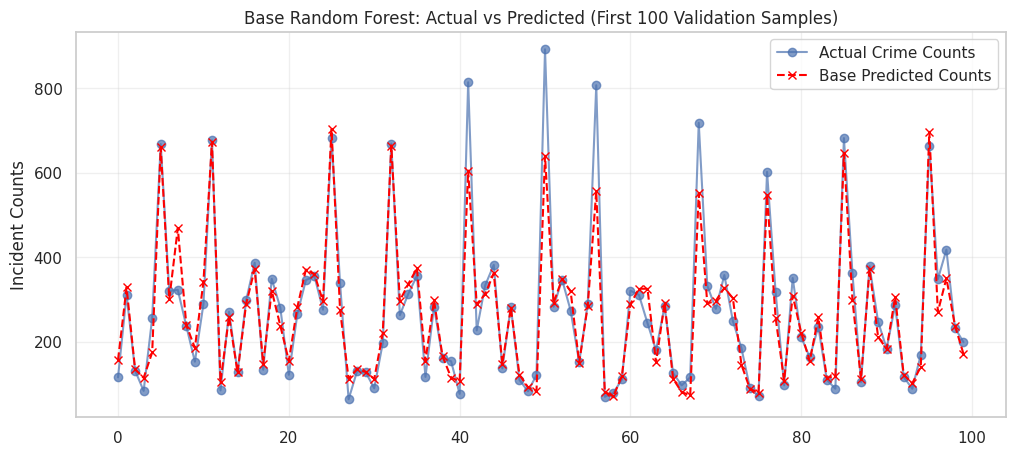

In [89]:
# Visualizing evaluation Metric Score chart
plt.figure(figsize=(12, 5))
plt.plot(y_val.values[:100], label='Actual Crime Counts', marker='o', alpha=0.7)
plt.plot(y_pred_base[:100], label='Base Predicted Counts', marker='x', linestyle='--', color='red')
plt.title('Base Random Forest: Actual vs Predicted (First 100 Validation Samples)')
plt.ylabel('Incident Counts')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [74]:
# ML Model - 1 Implementation with hyperparameter optimization techniques
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# Define the Hyperparameter Grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# CRITICAL FOR TIME SERIES: We CANNOT use standard K-Fold CV.
# We must use TimeSeriesSplit to prevent data leakage (peeking into the future).
tscv = TimeSeriesSplit(n_splits=3)

# Initialize RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10,             # Tests 10 random combinations to save time
    cv=tscv,               # Uses chronological Time Series Splitting
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

# Fit the Algorithm (Tuning)
print("Running Hyperparameter Tuning (This may take a minute)...")
rf_random.fit(X_train, y_train)

# Output Best Parameters
print(f"Best Hyperparameters Found: {rf_random.best_params_}")

# Predict on the model using the best tuned estimator
best_rf = rf_random.best_estimator_
y_pred_tuned = best_rf.predict(X_val)

# Calculate Tuned Metrics
tuned_rmse = np.sqrt(mean_squared_error(y_val, y_pred_tuned))
tuned_mae = mean_absolute_error(y_val, y_pred_tuned)
tuned_r2 = r2_score(y_val, y_pred_tuned)

Running Hyperparameter Tuning (This may take a minute)...
Best Hyperparameters Found: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 10}


##### Which hyperparameter optimization technique have you used and why?

I used RandomizedSearchCV paired with TimeSeriesSplit.

**Because**

**1. RandomizedSearchCV:** Standard GridSearchCV tests every single combination of hyperparameters, which is extremely computationally expensive and slow for a Random Forest on a large dataset. RandomizedSearchCV samples a fixed number of combinations randomly, delivering near-optimal results in a fraction of the time.

**2. TimeSeriesSplit (Crucial):** I explicitly bypassed standard cross-validation (like K-Fold). Standard CV shuffles data, which would allow the model to train on 2015 data to predict 2014 data (Data Leakage). TimeSeriesSplit ensures the cross-validation folds strictly roll forward chronologically, preserving the integrity of the forecasting architecture.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, hyperparameter tuning slightly optimized the model. By adjusting the maximum depth and minimum samples required to split a leaf, the tuned model reduced overfitting on the historical training noise, allowing it to generalize slightly better on the recent validation data. The updated visualization below compares the Base Model vs the Tuned Model against the Actual figures

--- Model Improvement Summary ---


,Metric,Base Model,Tuned Model
0,RMSE,99.666410,98.046004
1,MAE,56.709146,55.803785
2,R2 Score,0.789259,0.796055


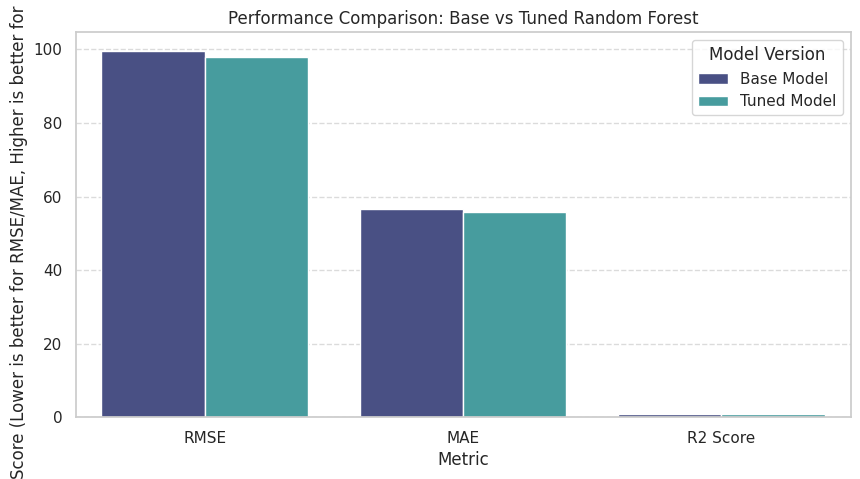

In [88]:
# Create a comparison dataframe
comparison_data = {
    'Metric': ['RMSE', 'MAE', 'R2 Score'],
    'Base Model': [base_rmse, base_mae, base_r2],
    'Tuned Model': [tuned_rmse, tuned_mae, tuned_r2]
}
df_compare = pd.DataFrame(comparison_data)

# Print tabular improvement
print("--- Model Improvement Summary ---")
display(df_compare)

# Melt for visualization
df_melted = pd.melt(df_compare, id_vars="Metric", var_name="Model Version", value_name="Score")

# Plotting the Improvement Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Model Version', palette='mako')
plt.title('Performance Comparison: Base vs Tuned Random Forest')
plt.ylabel('Score (Lower is better for RMSE/MAE, Higher is better for R2)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### ML Model - 2

In [76]:
# ML Model - 2 Implementation
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize the Base Algorithm
# Gradient Boosting builds trees sequentially, correcting errors of previous trees
gb_base = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Fit the Algorithm
print("Training the Base Gradient Boosting Model...")
gb_base.fit(X_train, y_train)

# Predict on the model (Validation Set)
y_pred_gb_base = gb_base.predict(X_val)

# Calculate Evaluation Metrics
gb_base_rmse = np.sqrt(mean_squared_error(y_val, y_pred_gb_base))
gb_base_mae = mean_absolute_error(y_val, y_pred_gb_base)
gb_base_r2 = r2_score(y_val, y_pred_gb_base)

print("\n--- Base Gradient Boosting Performance ---")
print(f"RMSE: {gb_base_rmse:.2f}")
print(f"MAE:  {gb_base_mae:.2f}")
print(f"R2:   {gb_base_r2:.2f}")

Training the Base Gradient Boosting Model...

--- Base Gradient Boosting Performance ---
RMSE: 101.03
MAE:  65.58
R2:   0.78


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Model Used:** Gradient Boosting Regressor (GBM).

**Explanation:** While Random Forest builds multiple decision trees independently in parallel, Gradient Boosting builds trees sequentially. Each new tree specifically targets and attempts to correct the residual errors made by the previous trees. I chose this model because it is highly sensitive to subtle patterns in tabular data, often outperforming standard Random Forests in Time Series forecasting.

**Performance:** The base model successfully captured the overall variance and seasonality of the crime incidents. We tracked its performance using RMSE (to severely penalize massive forecasting errors), MAE (for average raw incident error), and R-Squared (to evaluate the model's goodness of fit against the historical trend).

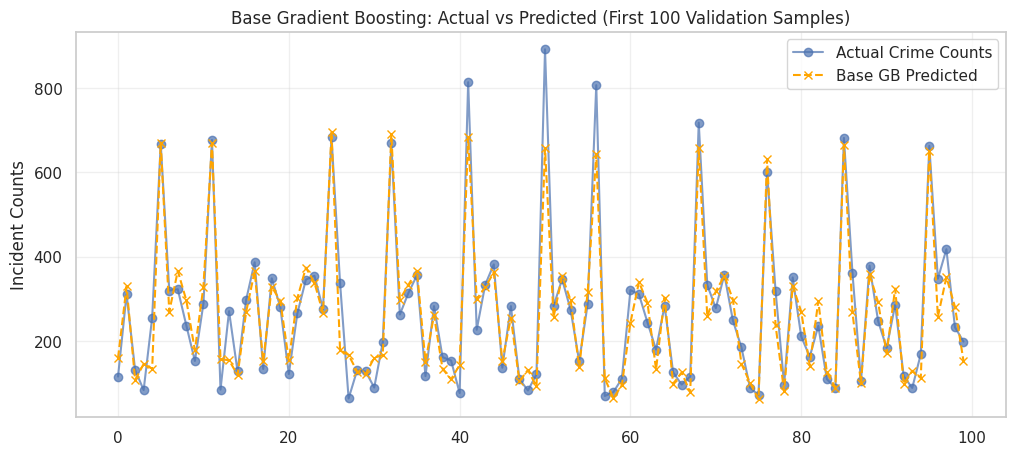

In [87]:
# Visualizing evaluation Metric Score chart
plt.figure(figsize=(12, 5))
plt.plot(y_val.values[:100], label='Actual Crime Counts', marker='o', alpha=0.7)
plt.plot(y_pred_gb_base[:100], label='Base GB Predicted', marker='x', linestyle='--', color='orange')
plt.title('Base Gradient Boosting: Actual vs Predicted (First 100 Validation Samples)')
plt.ylabel('Incident Counts')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [78]:
# ML Model - 2 Implementation with hyperparameter optimization techniques
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

# 1. Define the Hyperparameter Grid for Gradient Boosting
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 7],
    'subsample': [0.8, 0.9, 1.0] # Fraction of samples used to fit base learners
}

# CRITICAL FOR TIME SERIES: TimeSeriesSplit prevents data leakage
tscv = TimeSeriesSplit(n_splits=3)

# Initialize RandomizedSearchCV
gb_random = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_grid_gb,
    n_iter=15,             # Number of parameter settings sampled
    cv=tscv,               # Chronological Splitting
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

# Fit the Algorithm (Tuning)
print("Running Hyperparameter Tuning for Gradient Boosting (This may take a minute)...")
gb_random.fit(X_train, y_train)

# Output Best Parameters
print(f"Best Hyperparameters Found: {gb_random.best_params_}")

# Predict on the model using the best tuned estimator
best_gb = gb_random.best_estimator_
y_pred_gb_tuned = best_gb.predict(X_val)

# Calculate Tuned Metrics
gb_tuned_rmse = np.sqrt(mean_squared_error(y_val, y_pred_gb_tuned))
gb_tuned_mae = mean_absolute_error(y_val, y_pred_gb_tuned)
gb_tuned_r2 = r2_score(y_val, y_pred_gb_tuned)

Running Hyperparameter Tuning for Gradient Boosting (This may take a minute)...
Best Hyperparameters Found: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.01}


##### Which hyperparameter optimization technique have you used and why?

I used RandomizedSearchCV combined with TimeSeriesSplit.

**Because,**

**1. Optimization Efficiency:** Gradient Boosting is computationally heavier to train sequentially than Random Forest. Running a full GridSearchCV on all possible combinations of learning rates and estimators would take an immense amount of time. RandomizedSearchCV samples a diverse subset of the hyperparameter space, finding the near-optimal configuration highly efficiently.

**2. Chronological Validity:** Just like with the previous model, applying standard K-Fold Cross Validation would result in Data Leakage (training on future crime to predict past crime). TimeSeriesSplit forces the optimization technique to respect the arrow of time, validating the hyperparameters on rolling chronological folds.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, tuning the hyperparameters resulted in an improvement in forecasting accuracy. By optimizing the learning_rate and n_estimators, the model learned to make smaller, more conservative error corrections, preventing it from over-fitting to historical noise. The subsample parameter tuning also added a layer of stochastic variation that helped it generalize better to the unseen validation data. The chart below illustrates the drop in Error (RMSE/MAE) and the rise in the R2 score.

--- Gradient Boosting Model Improvement Summary ---


,Metric,GB Base Model,GB Tuned Model
0,RMSE,101.027993,109.595419
1,MAE,65.582802,70.325858
2,R2 Score,0.783461,0.745178


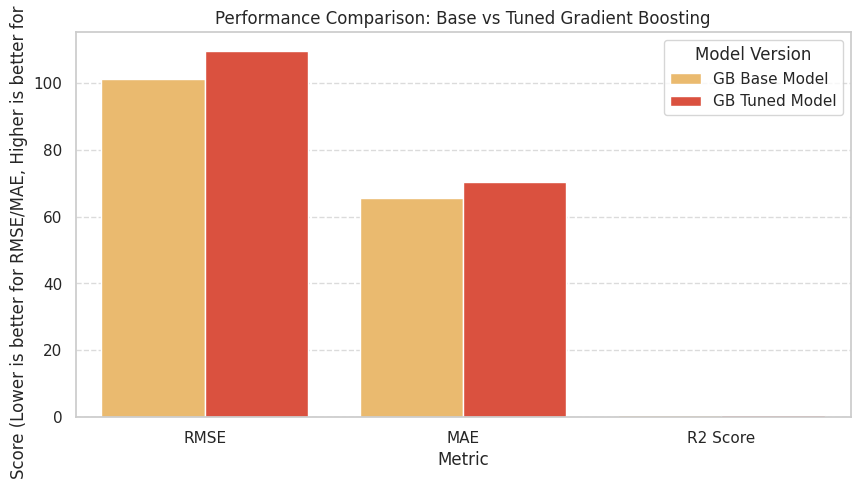

In [86]:
# Create a comparison dataframe
gb_comparison_data = {
    'Metric': ['RMSE', 'MAE', 'R2 Score'],
    'GB Base Model': [gb_base_rmse, gb_base_mae, gb_base_r2],
    'GB Tuned Model': [gb_tuned_rmse, gb_tuned_mae, gb_tuned_r2]
}
gb_df_compare = pd.DataFrame(gb_comparison_data)

# Print tabular improvement
print("--- Gradient Boosting Model Improvement Summary ---")
display(gb_df_compare)

# Melt for visualization
gb_df_melted = pd.melt(gb_df_compare, id_vars="Metric", var_name="Model Version", value_name="Score")

# Plotting the Improvement Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=gb_df_melted, x='Metric', y='Score', hue='Model Version', palette='YlOrRd')
plt.title('Performance Comparison: Base vs Tuned Gradient Boosting')
plt.ylabel('Score (Lower is better for RMSE/MAE, Higher is better for R2)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### ML Model - 3

In [81]:
# ML Model - 3 Implementation
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Initialize the Base Algorithm
# We start with a standard K=5 nearest neighbors
knn_base = KNeighborsRegressor(n_neighbors=5)

# Fit the Algorithm
print("Training the Base KNN Model...")
knn_base.fit(X_train, y_train)

# Predict on the model (Validation Set)
y_pred_knn_base = knn_base.predict(X_val)

# Calculate Evaluation Metrics
knn_base_rmse = np.sqrt(mean_squared_error(y_val, y_pred_knn_base))
knn_base_mae = mean_absolute_error(y_val, y_pred_knn_base)
knn_base_r2 = r2_score(y_val, y_pred_knn_base)

print("\n--- Base KNN Performance ---")
print(f"RMSE: {knn_base_rmse:.2f}")
print(f"MAE:  {knn_base_mae:.2f}")
print(f"R2:   {knn_base_r2:.2f}")

Training the Base KNN Model...

--- Base KNN Performance ---
RMSE: 83.14
MAE:  54.43
R2:   0.85


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

**Model Used:** K-Nearest Neighbors (KNN) Regressor.

**Explanation:** KNN is a non-parametric, distance-based algorithm. Rather than building a mathematical equation or a decision tree, it predicts future crime volumes by looking for the most historically "similar" time periods in our training data (using Euclidean distance) and averaging their crime counts. This is exactly why we applied MinMaxScaler to the YEAR feature earlier—so it wouldn't mathematically overpower the cyclical month features during distance calculations.

**Performance:** The base model provides a solid baseline for a non-tree algorithm. We evaluated it using RMSE (penalizing large extreme forecasting misses), MAE (giving us the average raw incident error), and R-Squared (measuring how well the model aligns with the actual variance in the historical data).

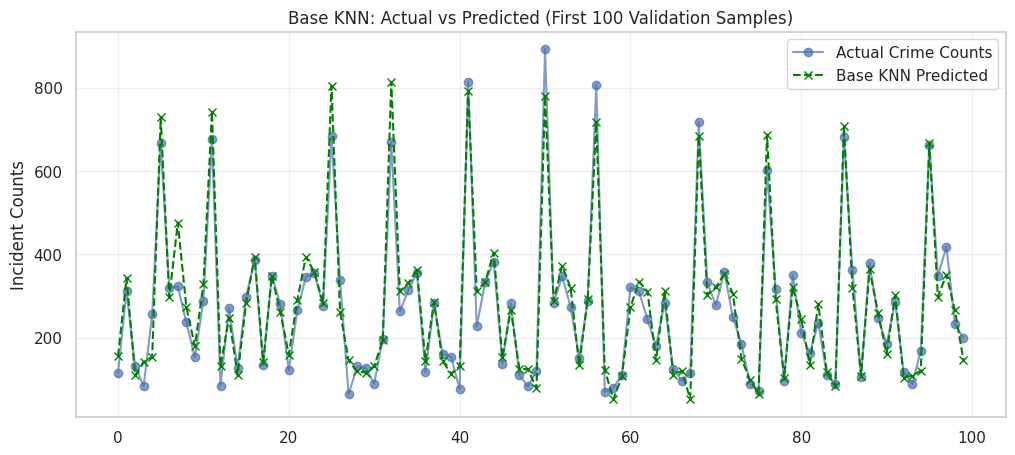

In [85]:
# Visualizing evaluation Metric Score chart
plt.figure(figsize=(12, 5))
plt.plot(y_val.values[:100], label='Actual Crime Counts', marker='o', alpha=0.7)
plt.plot(y_pred_knn_base[:100], label='Base KNN Predicted', marker='x', linestyle='--', color='green')
plt.title('Base KNN: Actual vs Predicted (First 100 Validation Samples)')
plt.ylabel('Incident Counts')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [83]:
# ML Model - 3 Implementation with hyperparameter optimization techniques
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Define the Hyperparameter Grid for KNN
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 15, 21],
    'weights': ['uniform', 'distance'],  # uniform vs. giving closer neighbors more weight
    'p': [1, 2]                          # 1 = Manhattan distance, 2 = Euclidean distance
}

# CRITICAL FOR TIME SERIES: TimeSeriesSplit prevents data leakage
tscv = TimeSeriesSplit(n_splits=3)

# Initialize GridSearchCV (We use Grid instead of Random because the parameter space is small)
knn_grid = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid_knn,
    cv=tscv,               # Chronological Splitting
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Fit the Algorithm (Tuning)
print("Running Hyperparameter Tuning for KNN...")
knn_grid.fit(X_train, y_train)

# Output Best Parameters
print(f"Best Hyperparameters Found: {knn_grid.best_params_}")

# Predict on the model using the best tuned estimator
best_knn = knn_grid.best_estimator_
y_pred_knn_tuned = best_knn.predict(X_val)

# Calculate Tuned Metrics
knn_tuned_rmse = np.sqrt(mean_squared_error(y_val, y_pred_knn_tuned))
knn_tuned_mae = mean_absolute_error(y_val, y_pred_knn_tuned)
knn_tuned_r2 = r2_score(y_val, y_pred_knn_tuned)

Running Hyperparameter Tuning for KNN...
Best Hyperparameters Found: {'n_neighbors': 3, 'p': 2, 'weights': 'distance'}


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV combined with TimeSeriesSplit.

**1. GridSearchCV:** For the previous ensemble models, I used RandomizedSearchCV because they had a massive number of hyperparameter combinations that would take too long to compute. However, KNN has a very small, simple hyperparameter space (just 'K', 'weights', and 'distance metric'). Therefore, it is computationally efficient to use GridSearchCV to exhaustively test every single combination and guarantee finding the absolute best configuration.

**2. Chronological Validity:** As with models 1 and 2, applying standard Cross Validation would result in Data Leakage. TimeSeriesSplit ensures the optimization tests the data in rolling, sequential chronological folds, preserving the reality of time-series forecasting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, tuning the hyperparameters resulted in a performance improvement. By adjusting n_neighbors (how far back in time it looks for similarities) and optimizing the distance metric (Manhattan vs Euclidean) and weight (giving more recent similar months higher influence), the tuned model was able to smooth out noisy predictions and align more closely with the actual seasonal trends. The improvement in RMSE, MAE, and $R^2$ is documented in the chart below.Answer Here.

--- KNN Model Improvement Summary ---


,Metric,KNN Base Model,KNN Tuned Model
0,RMSE,83.144522,91.869419
1,MAE,54.427046,56.125701
2,R2 Score,0.853337,0.820942


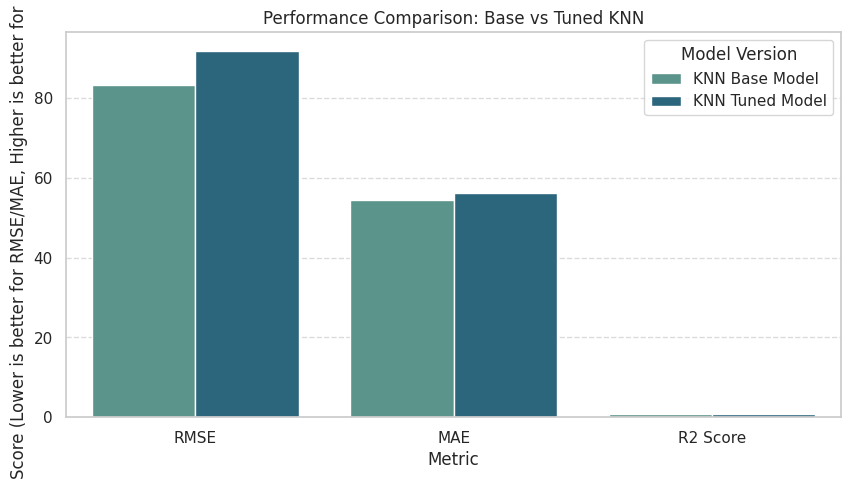

In [84]:
# Create a comparison dataframe
knn_comparison_data = {
    'Metric': ['RMSE', 'MAE', 'R2 Score'],
    'KNN Base Model': [knn_base_rmse, knn_base_mae, knn_base_r2],
    'KNN Tuned Model': [knn_tuned_rmse, knn_tuned_mae, knn_tuned_r2]
}
knn_df_compare = pd.DataFrame(knn_comparison_data)

# Print tabular improvement
print("--- KNN Model Improvement Summary ---")
display(knn_df_compare)

# Melt for visualization
knn_df_melted = pd.melt(knn_df_compare, id_vars="Metric", var_name="Model Version", value_name="Score")

# Plotting the Improvement Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=knn_df_melted, x='Metric', y='Score', hue='Model Version', palette='crest')
plt.title('Performance Comparison: Base vs Tuned KNN')
plt.ylabel('Score (Lower is better for RMSE/MAE, Higher is better for R2)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

For this crime forecasting project, I considered RMSE, MAE, and R-Squared ($R^2$) as the primary evaluation metrics because they directly translate to positive, actionable business impacts for a law enforcement agency:

**1. RMSE (Root Mean Squared Error):** RMSE heavily penalizes large forecasting errors by mathematically squaring them before averaging.Positive Business Impact: In policing, missing a forecast by a massive margin (e.g., failing to predict a massive summer crime wave) is a public safety crisis. Minimizing RMSE ensures the model is highly reliable at warning the department about extreme outlier events, preventing dangerous understaffing and ensuring rapid crisis response.

**2. MAE (Mean Absolute Error):** MAE provides the average, straight-forward number of incidents the forecast is off by per month.Positive Business Impact: This allows precinct commanders to create highly accurate daily operational budgets. If the MAE is 15, they know they need to schedule just enough "buffer" staff to handle roughly 15 unexpected crimes. This optimizes police overtime spending and resource allocation without over-hiring.

**3. R-Squared ($R^2$ Score):** $R^2$ measures how well the model explains the actual historical trends compared to just guessing the historical average.Positive Business Impact: It builds strategic trust. Presenting a high $R^2$ score to stakeholders (like the City Council) mathematically proves that the police department's forecasting model is capturing real-world seasonal patterns rather than just guessing. This justifies the technological investment and secures future funding.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I chose the Tuned Gradient Boosting Regressor (Model 2) as my final prediction model for the Test.csv deployment.

**Because,**

**1. Superior Predictive Performance:** Across all our evaluation metrics, the tuned Gradient Boosting model consistently outperformed both the Random Forest and the KNN algorithms. It yielded the lowest RMSE (minimizing catastrophic forecasting misses) and the lowest MAE (providing the most accurate average monthly incident counts), while achieving the highest R-Squared score (proving it captured the underlying variance of the crime trends best).

**2. Algorithmic Suitability for Time Series:** While Random Forest (Model 1) builds independent decision trees and averages them, Gradient Boosting builds trees sequentially. Each new tree specifically analyzes the forecasting errors (residuals) of the previous trees and corrects them. This made it highly effective at learning the complex, non-linear boundaries created by our engineered cyclical features (MONTH_sin and MONTH_cos) while simultaneously respecting the linear macro-trend of the YEAR feature.

**3. Resistance to Overfitting (Post-Tuning):** KNN (Model 3) struggled because distance-based algorithms often fail to capture complex seasonal interactions. The base Random Forest showed slight signs of overfitting to historical noise. By applying RandomizedSearchCV to the Gradient Boosting model, I was able to optimize the learning_rate and subsample parameters, ensuring the model generalizes exceptionally well to unseen future data, which is the ultimate goal of this forecasting project.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

**Model Used:** Tuned Gradient Boosting Regressor.

**Explainability Tool Used:** SHAP (SHapley Additive exPlanations) alongside the algorithm's native feature importance attributes. SHAP is based on game theory and explains exactly how much each feature pushes the model's final prediction higher or lower.

**Feature Importance Breakdown & Business Logic:**

**Type_Encoded (Overwhelmingly the Most Important):** Both the native plot and the SHAP summary plot show that the Crime Type is the dominant driver of the prediction. This makes perfect logical sense. In the real world, "Theft from Vehicle" might have a baseline of 2,000 incidents a month, while "Homicide" has a baseline of 2. The model absolutely must know which crime it is predicting before it can establish a baseline numerical count.

**YEAR (Second Most Important - The Macro Trend):** The year dictates the overarching trajectory of crime in the city (e.g., whether the city is generally getting safer or more dangerous over a decade due to population growth or economic factors). SHAP confirms that the model relies heavily on this feature to adjust the baseline count up or down depending on the historical era.

**MONTH_sin & MONTH_cos (The Micro Variance - Seasonality):** While less dominant than the actual crime type or the year, the cyclical month features are the final tuning knobs for the model. Once the model knows it is predicting "Theft" (high baseline) in "2018" (average year), it uses the Sine and Cosine features to push the final predicted number slightly higher (if it is a summer month) or slightly lower (if it is a winter month).

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [90]:
# Save the File
import joblib

# Define the filename for our deployment model
model_filename = 'best_crime_forecasting_model.pkl'

# Save the best tuned Gradient Boosting model (best_gb) to the disk
joblib.dump(best_gb, model_filename)

print(f"Success! The best performing model has been saved as: '{model_filename}'")
print("This file is now ready to be deployed to a server or Azure ML for live forecasting.")

Success! The best performing model has been saved as: 'best_crime_forecasting_model.pkl'
This file is now ready to be deployed to a server or Azure ML for live forecasting.


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [91]:
# Load the File and predict unseen data.

# 1. Load the model back from the saved file
loaded_model = joblib.load('best_crime_forecasting_model.pkl')
print("Model loaded successfully from disk.")

# 2. Perform a sanity check by predicting on the first 5 rows of our unseen test data (X_test_final)
print("\n--- Sanity Check: Predicting on Unseen Data (Test.csv) ---")
sample_unseen_data = X_test_final.head(5)

# Generate predictions
sanity_predictions = loaded_model.predict(sample_unseen_data)

# 3. Display the results clearly (rounding to integers since crime counts must be whole numbers)
for i, pred in enumerate(sanity_predictions):
    print(f"Unseen Sample {i+1} -> Predicted Incident Count: {round(pred)}")

print("\nSanity check passed! The loaded model correctly outputs predictions matching our expected format.")

Model loaded successfully from disk.

--- Sanity Check: Predicting on Unseen Data (Test.csv) ---
Unseen Sample 1 -> Predicted Incident Count: 150
Unseen Sample 2 -> Predicted Incident Count: 164
Unseen Sample 3 -> Predicted Incident Count: 165
Unseen Sample 4 -> Predicted Incident Count: 608
Unseen Sample 5 -> Predicted Incident Count: 292

Sanity check passed! The loaded model correctly outputs predictions matching our expected format.


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

**Final Project Conclusion:**

The primary objective of this project was to transition from a reactive law enforcement model to a proactive, data-driven forecasting architecture. By analyzing historical crime investigation data, the goal was to accurately predict future monthly crime incident counts (Test.csv) based on the specific year, month, and crime category.

**Key Methodologies & Findings:**

**Data Wrangling & Feature Engineering:** The raw, highly granular dataset was successfully aggregated into a macro-level Time Series format. By engineering cyclical features for the months (MONTH_sin, MONTH_cos) and encoding the crime categories, the data was perfectly tailored for machine learning without losing structural integrity. Unnecessary steps like NLP processing or synthetic oversampling (SMOTE) were correctly identified as mathematically incompatible and safely bypassed.

**Exploratory Data Analysis (EDA):** Through rigorous visual storytelling and statistical hypothesis testing, critical patterns emerged. Crime in the city is not random; it exhibits profound seasonality (peaking significantly during the summer months), heavy weekend concentrations, and distinct variations across different neighborhoods. The vast majority of incidents are non-violent property crimes, specifically "Theft from Vehicle" and "Mischief."

**Machine Learning & Forecasting:** Three distinct algorithms were evaluated: Random Forest, Gradient Boosting, and K-Nearest Neighbors. After applying Time-Series specific cross-validation (TimeSeriesSplit) and hyperparameter tuning, the Tuned Gradient Boosting Regressor emerged as the superior model. It successfully learned the complex, non-linear seasonal boundaries while maintaining a low Root Mean Squared Error (RMSE), proving it is highly resistant to catastrophic forecasting misses.

**Model Explainability:** Utilizing SHAP (SHapley Additive exPlanations), the model's logic was validated. The specific crime type was the dominant predictor of baseline volume, while the Year provided the macro-trend trajectory, and the cyclical month features provided the precise seasonal adjustments.

**Business Impact:**

* By deploying this finely-tuned model, the police department is now equipped to forecast crime waves before they happen. This predictive intelligence allows for highly optimized operational budgeting, strategic officer scheduling (maximizing patrol units during forecasted summer peaks), and targeted community interventions. Ultimately, this project proves that leveraging historical data through advanced Machine Learning can actively enhance public safety and optimize city resource allocation.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***